In [1]:
import torch
import numpy as np

from dataclasses import dataclass, field

from env.wrapper import EnvWrapper
from RL.ppo.ThrBLpolicy import PolicyNetwork
from RL.ppo.train_BLpolicy import PPOConfig, model_summary

from game.enums import BoardType, Tribes

C:\Users\laure\0envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device     = "cpu"#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(r'./RL/ppo/checkpoints_new/policy_update_00079.pt', weights_only=True, map_location=device)



In [4]:
@dataclass
class PPOConfig:

    # --- Parallelism ---
    n_processes:         int   = 8
    n_envs_per_process:  int   = 4

    # --- Environment ---
    # board_size is chosen randomly per episode; only type and player count
    # are fixed here.
    board_config_dict = {
        "board_type" : BoardType.Dummy,
        "n_players"  : 2,
    }
    player_tribes      = [Tribes.Omaji, Tribes.Imperius]
    max_turns_per_game = 100

    # --- Board size curriculum: uniform random square in [min, max] ──────────
    board_size_range:    tuple = (10, 16)

    # --- Rollout ---
    n_steps:             int   = 128

    # --- PPO epochs & batching ---
    n_epochs:            int   = 6
    n_minibatches:       int   = 4

    # --- PPO loss coefficients ---
    clip_eps:            float = 0.2
    vf_coef:             float = 0.5
    ent_coef:            float = 0.01
    max_grad_norm:       float = 0.5

    # --- GAE / discount ---
    gamma:               float = 0.99
    gae_lambda:          float = 0.95

    # --- Optimizer ---
    lr:                  float = 3e-4

    # --- Training ---
    n_updates:           int   = 20
    log_interval:        int   = 1

    # ── Model architecture ────────────────────────────────────────────────────
    mpnn_hidden_dim:     int   = 128    # GraphSAGE hidden size
    mlp_hidden_dim:      int   = 64   # MLP hidden layer width
    mlp_depth:           int   = 3     # number of hidden layers in every MLP

    @property
    def n_envs_total(self):
        return self.n_processes * self.n_envs_per_process

    @property
    def batch_size(self):
        return self.n_steps * self.n_envs_total

    @property
    def minibatch_size(self):
        return self.batch_size // self.n_minibatches

In [5]:
cfg = PPOConfig()
policy = PolicyNetwork(cfg).to(device)
policy.load_state_dict(checkpoint)
policy.eval()
model_summary(policy)

  Module                             Params
--------------------------------------------------------
  MPNN backbone                      72,576
  Action type head                   18,053
  Critic head                        17,793
  Move unit sel                      17,793
  Move target                        17,793
  Attack unit sel                    17,793
  Attack enemy sel                   17,793
  City sel                           17,793
  Unit type sel                      17,858
  Capture unit sel                   17,793
  TOTAL                             233,038
  TRAINABLE                         233,038
  Node embedding dim : 144
  Positional enc     : sinusoidal (0 params, any board size)


In [6]:
board_config_dict = {
        "board_type" : BoardType.Dummy,
        "n_players"  : 2,
        "board_size" : (10,10)
    }

In [7]:
def calc_probs_global_action_head(policy, obs, mask):
    N_tiles    = np.asarray(obs['partial_graph']).shape[0]
    Nx = Ny    = int(round(N_tiles ** 0.5))

    node_emb   = policy._encode(obs['partial_graph'], Nx, Ny)  # (N, node_dim)
    global_emb = node_emb.mean(dim=0, keepdim=True)
    #n_u, n_e, n_c = self._sizes(mask)

    logits = policy.action_type_head(global_emb).squeeze(0)
    print("logits: ", logits)
    return policy._dist(logits, mask[0]).probs
    

value: tensor(0.0456)
logits:  tensor([-0.3574,  1.4917,  2.8114,  3.5776, -5.9161],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


C:\Users\laure\1own_projects\1polytopia_score\env\wrapper.py:456: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


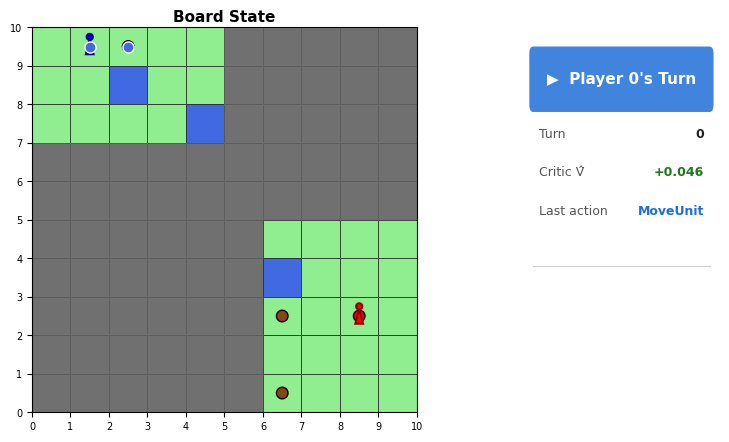

Warrior (10/10) in state idle
value: tensor(0.0419)
logits:  tensor([-0.3571,  1.4919,  2.8113,  3.5776, -5.9163],
       grad_fn=<SqueezeBackward1>)
tensor([0.0000e+00, 0.0000e+00, 9.9984e-01, 0.0000e+00, 1.6202e-04],
       grad_fn=<SoftmaxBackward0>)


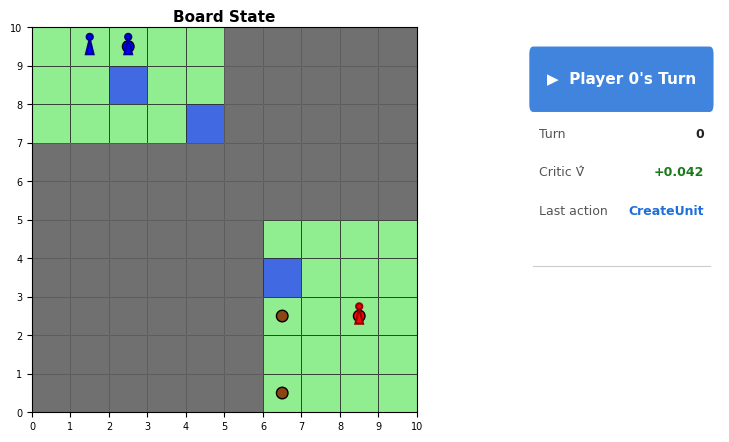

Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0320)
logits:  tensor([-0.3567,  1.4922,  2.8113,  3.5776, -5.9168],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


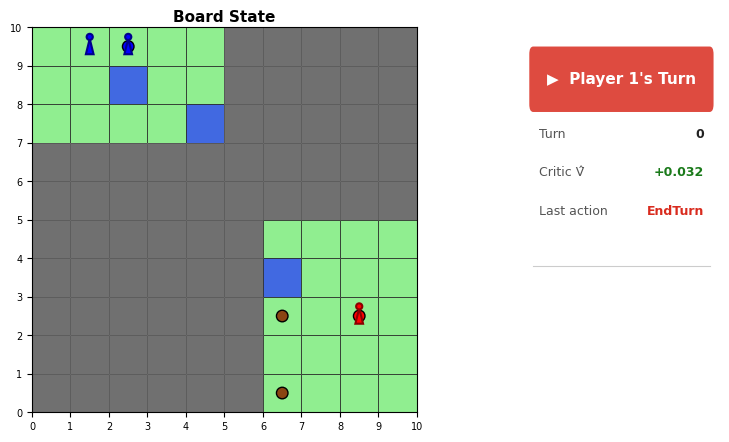

Warrior (10/10) in state ready
value: tensor(0.0767)
logits:  tensor([-0.3460,  1.4992,  2.8123,  3.5799, -5.9191],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


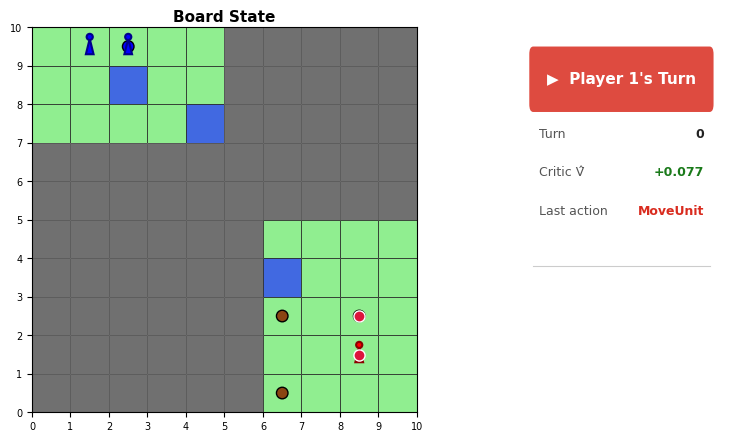

Warrior (10/10) in state idle
value: tensor(0.0703)
logits:  tensor([-0.3457,  1.4993,  2.8122,  3.5798, -5.9195],
       grad_fn=<SqueezeBackward1>)
tensor([0.0000e+00, 0.0000e+00, 9.9984e-01, 0.0000e+00, 1.6137e-04],
       grad_fn=<SoftmaxBackward0>)


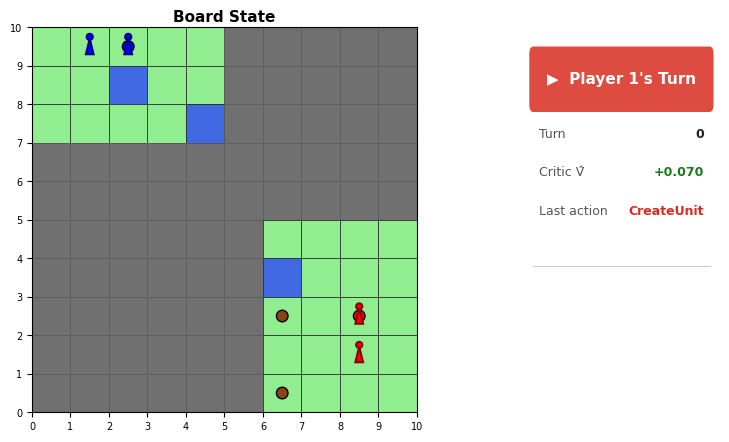

Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0505)
logits:  tensor([-0.3451,  1.4997,  2.8122,  3.5797, -5.9202],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


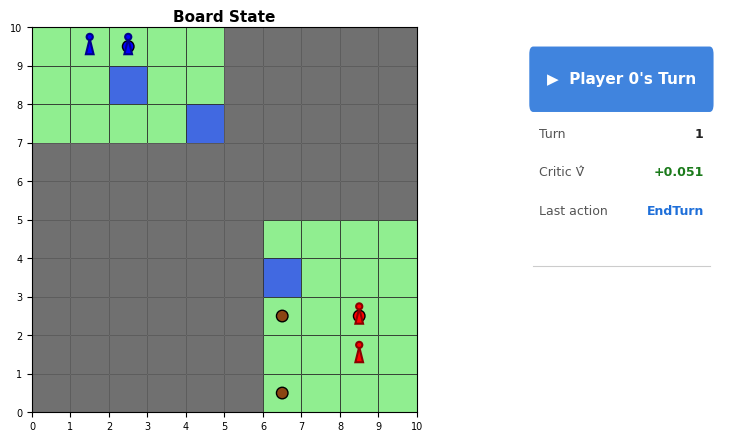

Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0320)
logits:  tensor([-0.3567,  1.4922,  2.8113,  3.5776, -5.9168],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


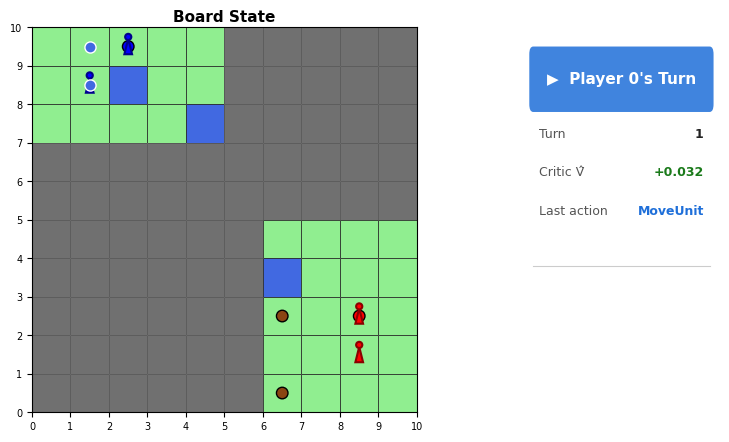

Warrior (10/10) in state idle
Warrior (10/10) in state ready
value: tensor(0.0545)
logits:  tensor([-0.3546,  1.4935,  2.8113,  3.5784, -5.9168],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


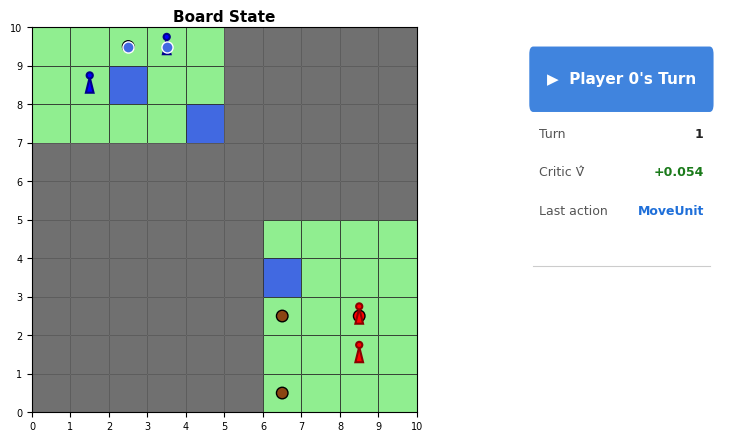

Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0200)
logits:  tensor([-0.3564,  1.4924,  2.8112,  3.5775, -5.9172],
       grad_fn=<SqueezeBackward1>)
tensor([0.0000e+00, 0.0000e+00, 9.9984e-01, 0.0000e+00, 1.6188e-04],
       grad_fn=<SoftmaxBackward0>)


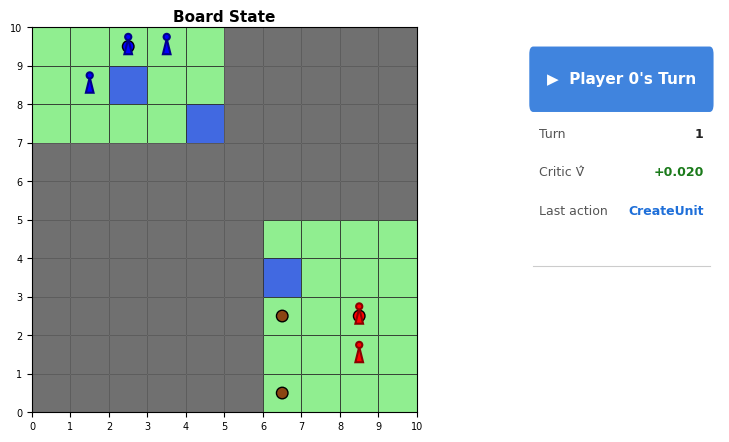

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0136)
logits:  tensor([-0.3559,  1.4927,  2.8113,  3.5775, -5.9176],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


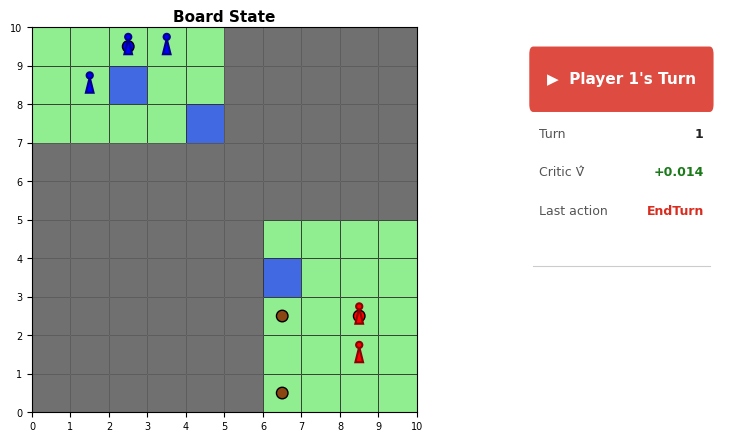

Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0505)
logits:  tensor([-0.3451,  1.4997,  2.8122,  3.5797, -5.9202],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


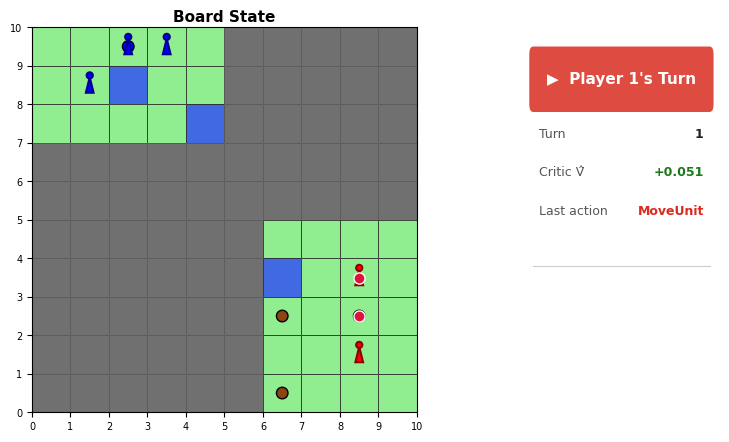

Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0994)
logits:  tensor([-0.3411,  1.5022,  2.8121,  3.5815, -5.9198],
       grad_fn=<SqueezeBackward1>)
tensor([4.0960e-02, 0.0000e+00, 9.5889e-01, 0.0000e+00, 1.5472e-04],
       grad_fn=<SoftmaxBackward0>)


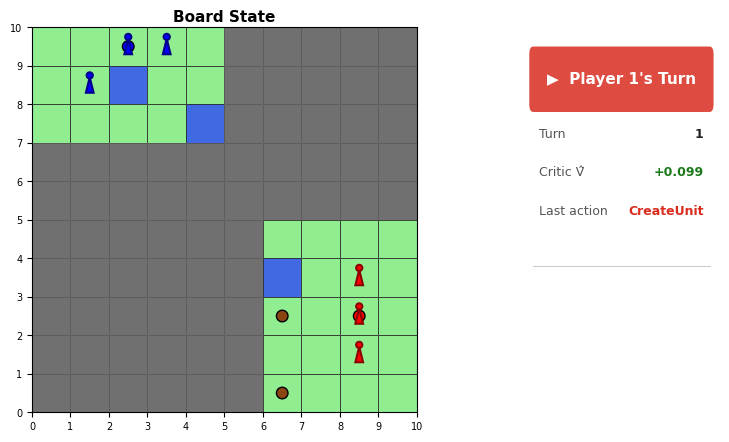

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0664)
logits:  tensor([-0.3411,  1.5020,  2.8120,  3.5811, -5.9205],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


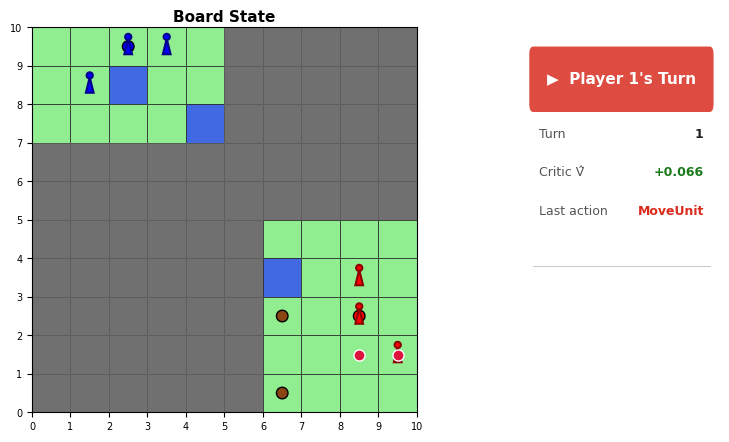

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0413)
logits:  tensor([-0.3447,  1.5000,  2.8121,  3.5796, -5.9206],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


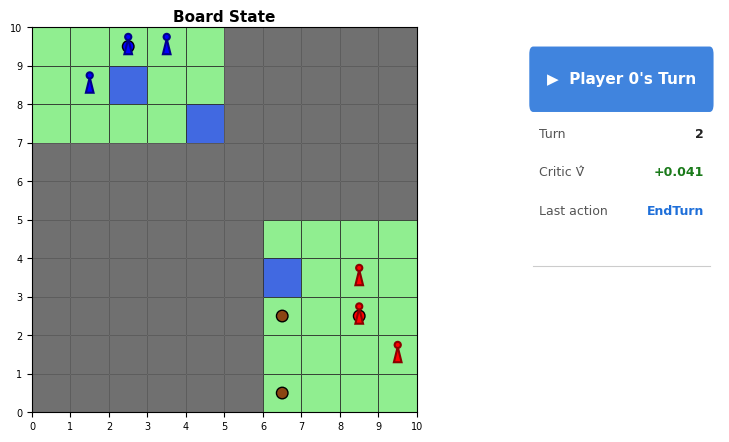

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0136)
logits:  tensor([-0.3559,  1.4927,  2.8113,  3.5775, -5.9176],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


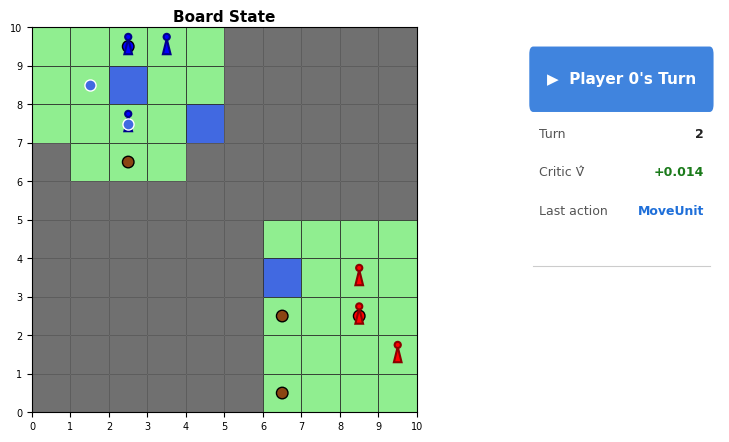

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0838)
logits:  tensor([-0.3458,  1.4991,  2.8118,  3.5804, -5.9186],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


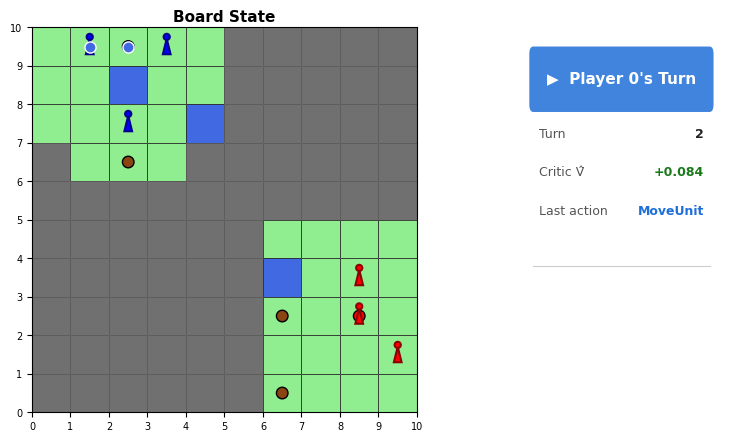

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0374)
logits:  tensor([-0.3478,  1.4978,  2.8116,  3.5794, -5.9192],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


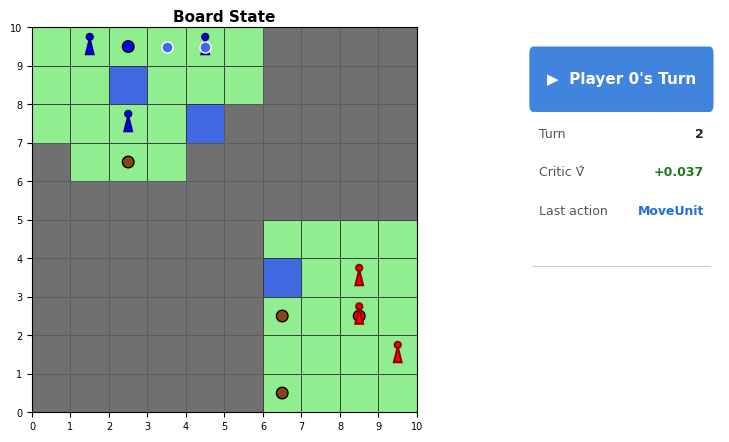

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0113)
logits:  tensor([-0.3471,  1.4984,  2.8119,  3.5788, -5.9204],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


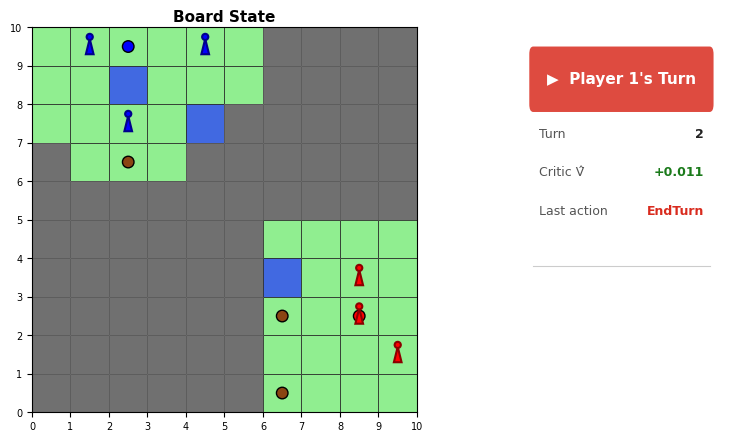

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0413)
logits:  tensor([-0.3447,  1.5000,  2.8121,  3.5796, -5.9206],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


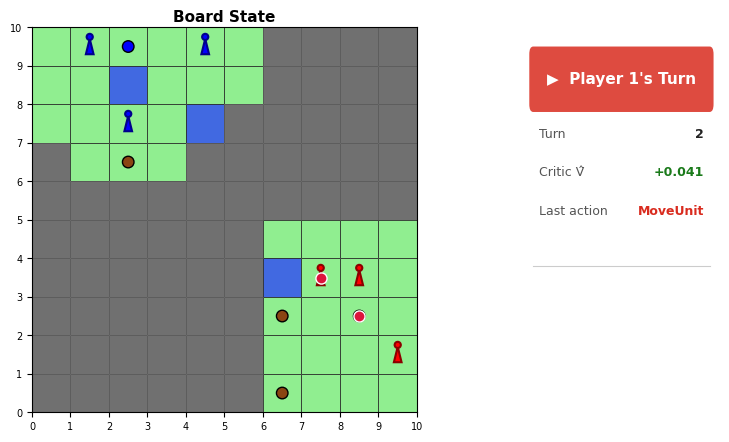

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.1050)
logits:  tensor([-0.3391,  1.5033,  2.8120,  3.5821, -5.9200],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


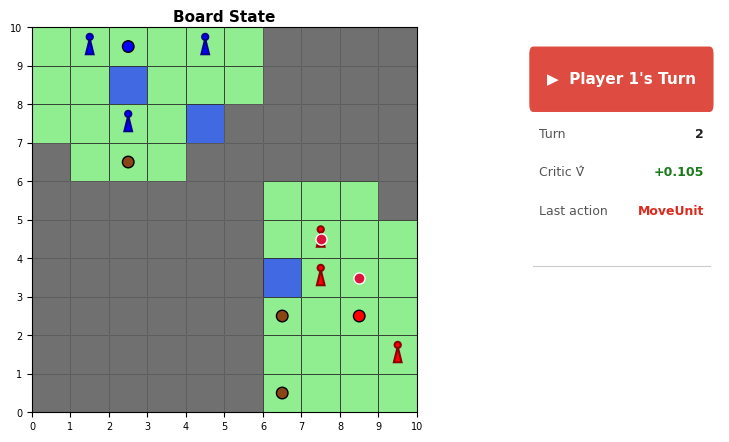

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0654)
logits:  tensor([-0.3379,  1.5042,  2.8127,  3.5813, -5.9216],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


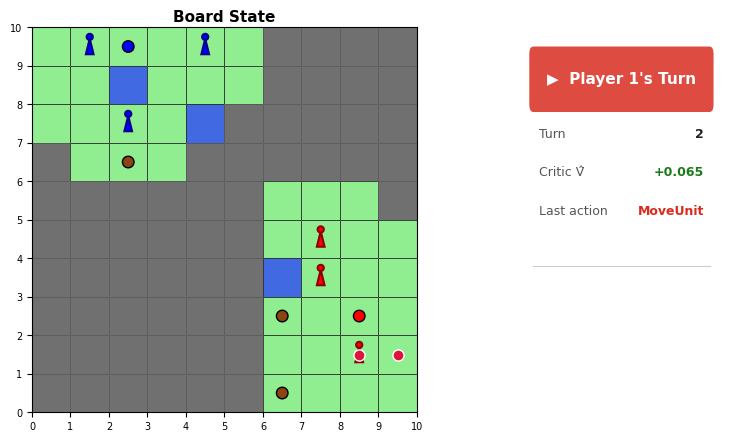

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0185)
logits:  tensor([-0.3404,  1.5027,  2.8127,  3.5799, -5.9223],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


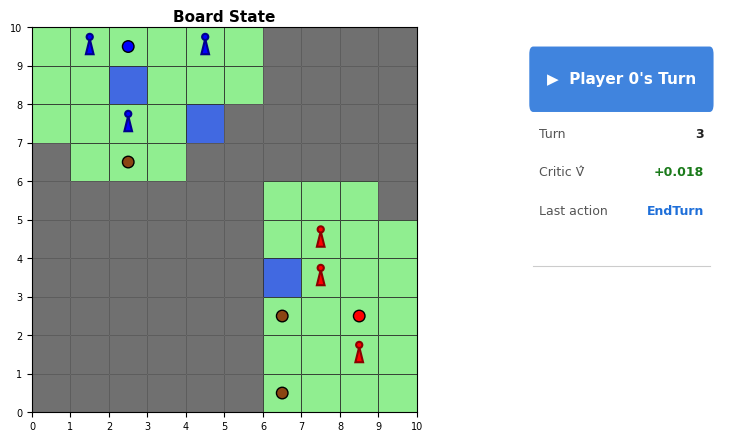

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0113)
logits:  tensor([-0.3471,  1.4984,  2.8119,  3.5788, -5.9204],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


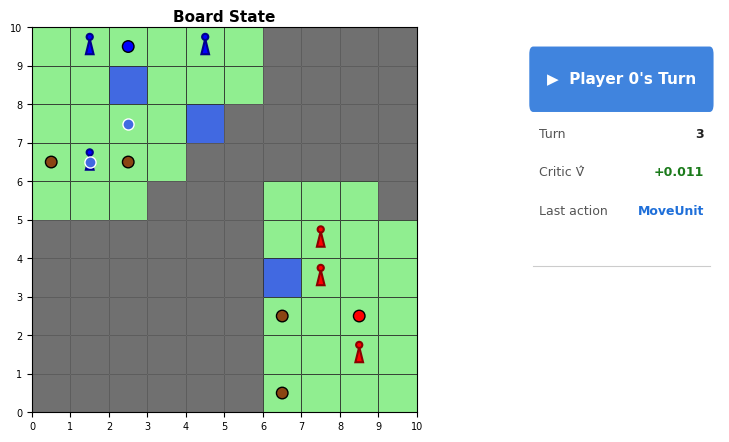

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0691)
logits:  tensor([-0.3351,  1.5059,  2.8125,  3.5821, -5.9218],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


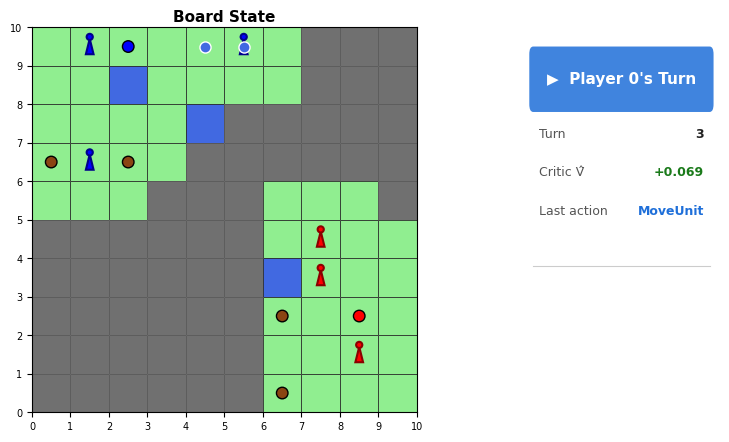

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state ready
value: tensor(0.0385)
logits:  tensor([-0.3350,  1.5061,  2.8128,  3.5812, -5.9228],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


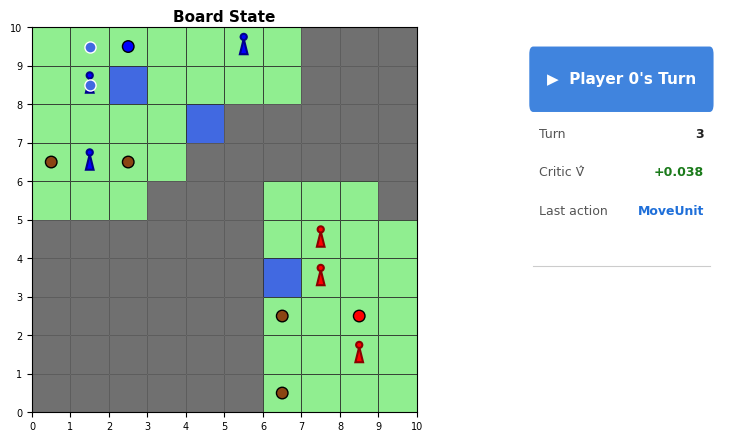

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0004)
logits:  tensor([-0.3368,  1.5048,  2.8130,  3.5801, -5.9234],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


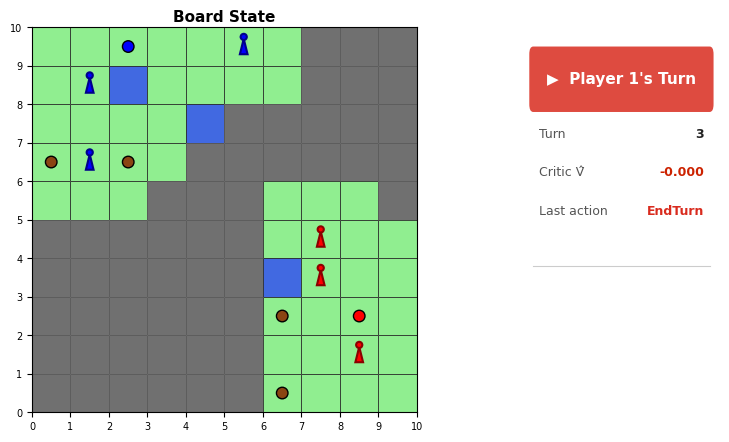

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0185)
logits:  tensor([-0.3404,  1.5027,  2.8127,  3.5799, -5.9223],
       grad_fn=<SqueezeBackward1>)
tensor([0.9962, 0.0000, 0.0000, 0.0000, 0.0038], grad_fn=<SoftmaxBackward0>)


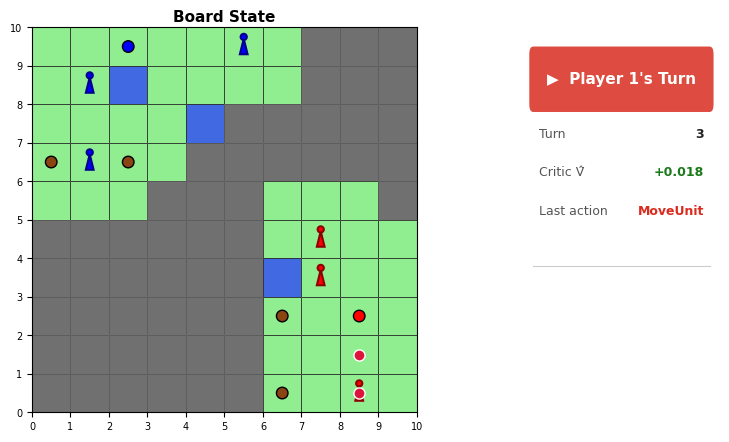

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.1092)
logits:  tensor([-0.3339,  1.5067,  2.8124,  3.5829, -5.9215],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


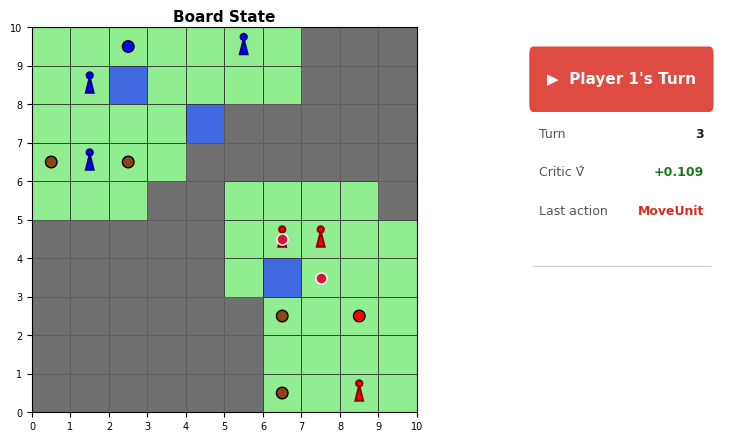

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0538)
logits:  tensor([-0.3337,  1.5069,  2.8131,  3.5816, -5.9229],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


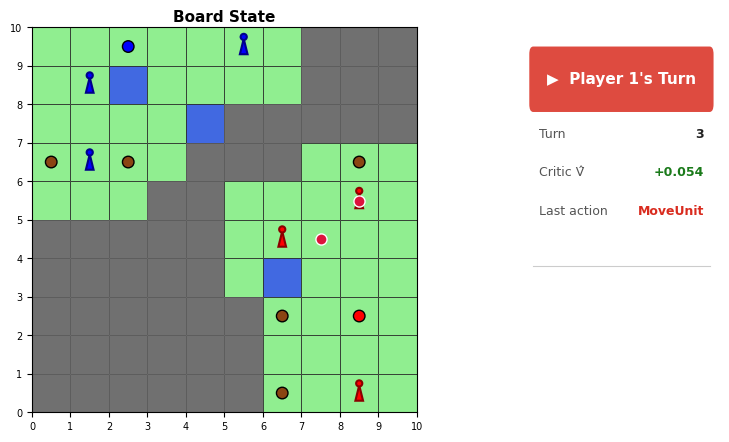

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0331)
logits:  tensor([-0.3287,  1.5101,  2.8138,  3.5815, -5.9251],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


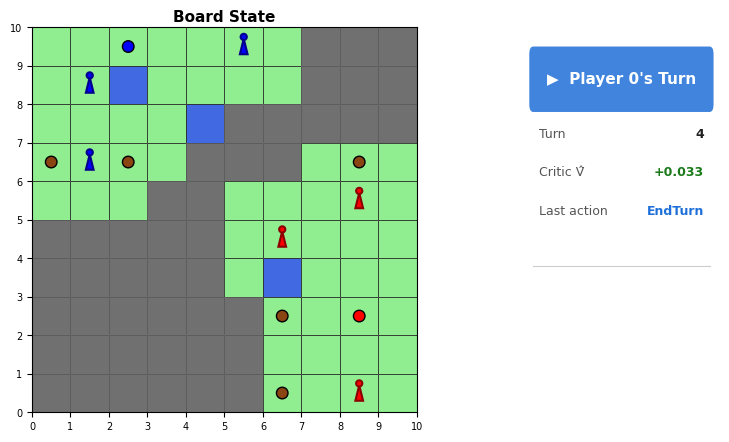

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(-0.0004)
logits:  tensor([-0.3368,  1.5048,  2.8130,  3.5801, -5.9234],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


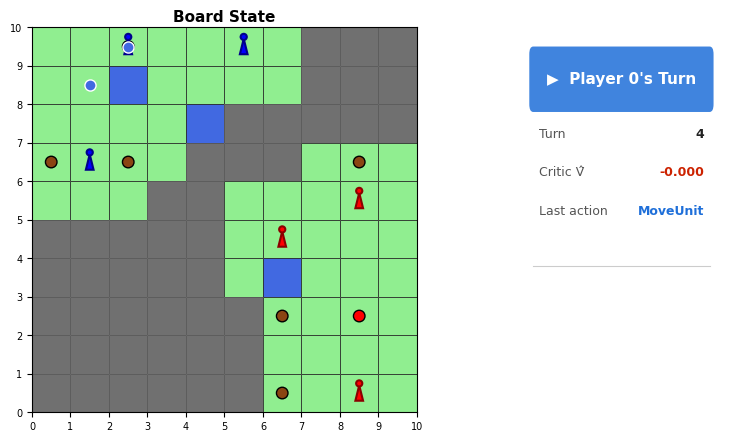

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0960)
logits:  tensor([-0.3303,  1.5090,  2.8127,  3.5833, -5.9225],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


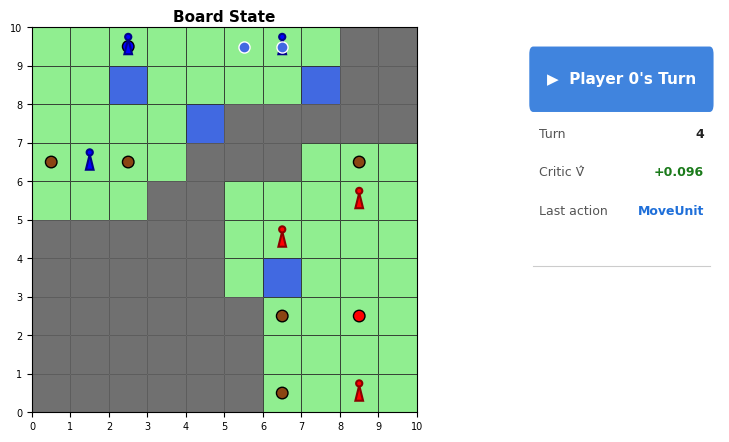

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0687)
logits:  tensor([-0.3303,  1.5092,  2.8130,  3.5826, -5.9233],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


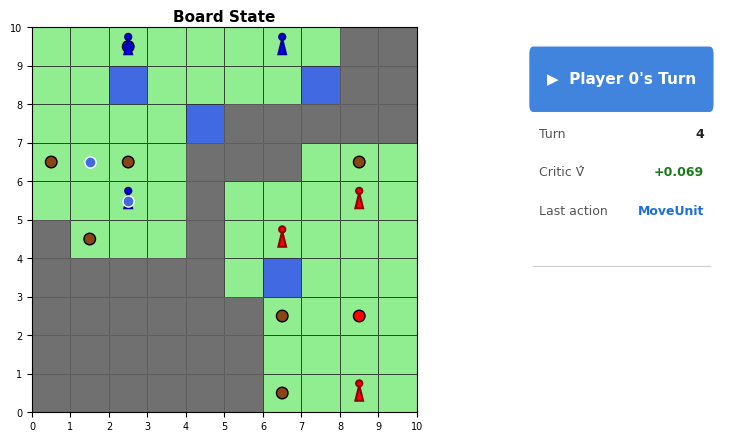

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0294)
logits:  tensor([-0.3275,  1.5111,  2.8140,  3.5818, -5.9251],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


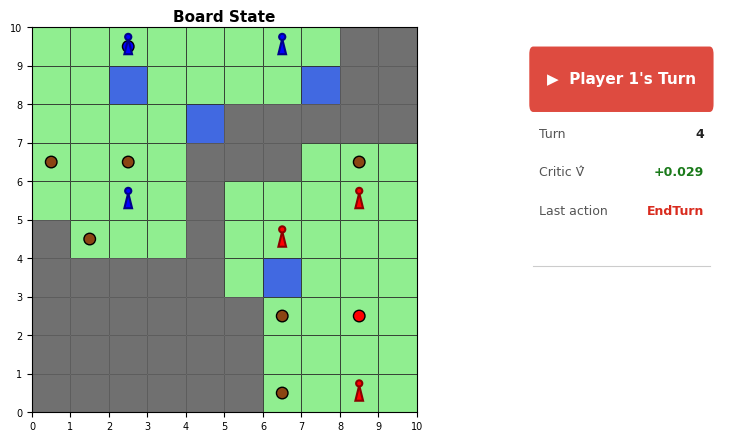

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0331)
logits:  tensor([-0.3287,  1.5101,  2.8138,  3.5815, -5.9251],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


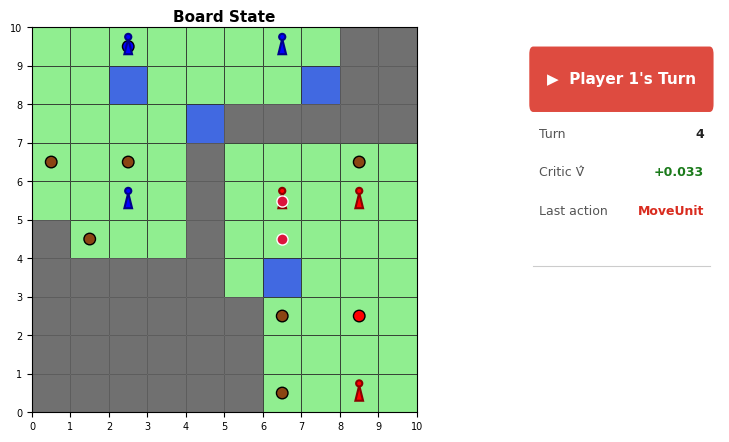

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.1212)
logits:  tensor([-0.3187,  1.5164,  2.8137,  3.5850, -5.9253],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


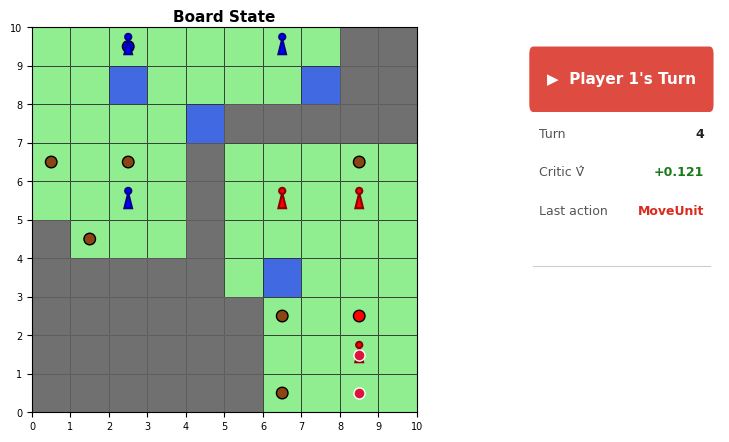

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0607)
logits:  tensor([-0.3218,  1.5142,  2.8140,  3.5833, -5.9259],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


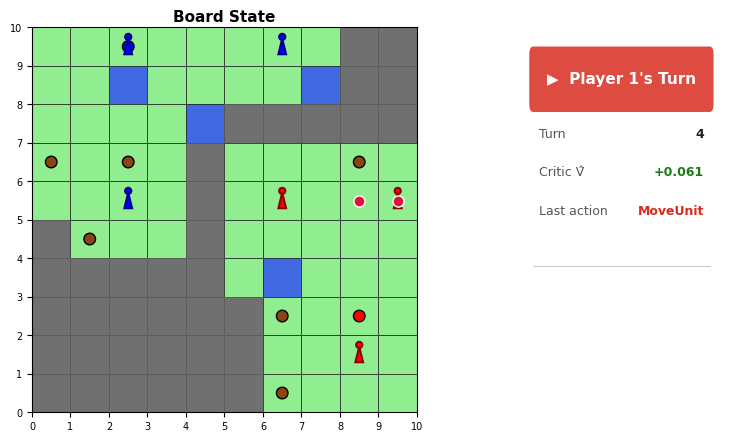

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0233)
logits:  tensor([-0.3260,  1.5117,  2.8142,  3.5816, -5.9259],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


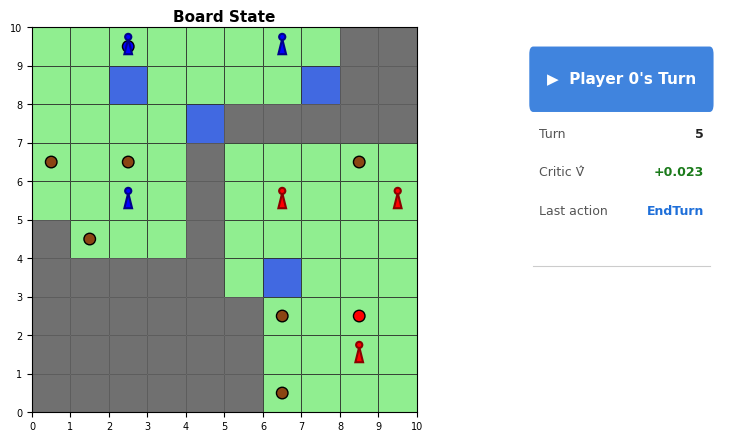

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0294)
logits:  tensor([-0.3275,  1.5111,  2.8140,  3.5818, -5.9251],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


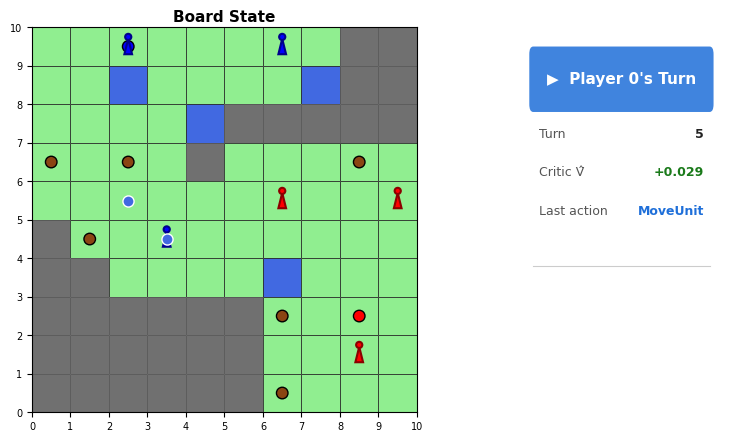

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.1034)
logits:  tensor([-0.3153,  1.5187,  2.8146,  3.5846, -5.9264],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


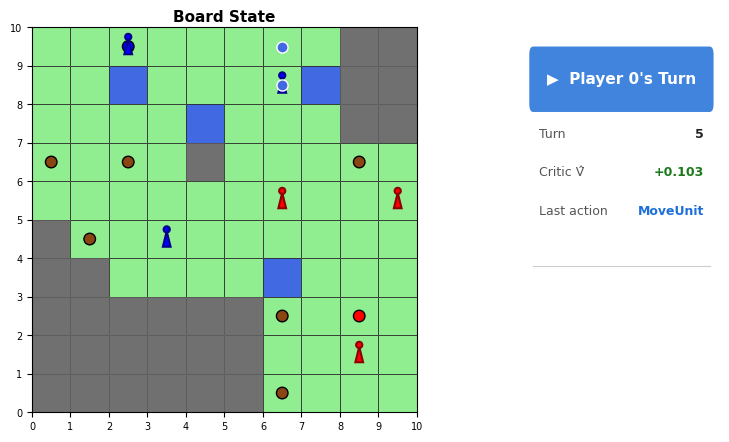

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state ready
value: tensor(0.0672)
logits:  tensor([-0.3124,  1.5203,  2.8153,  3.5839, -5.9281],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


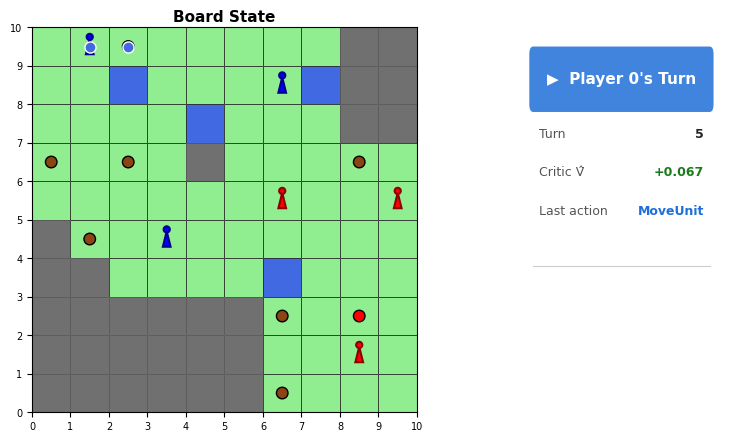

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0123)
logits:  tensor([-0.3147,  1.5187,  2.8154,  3.5827, -5.9286],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


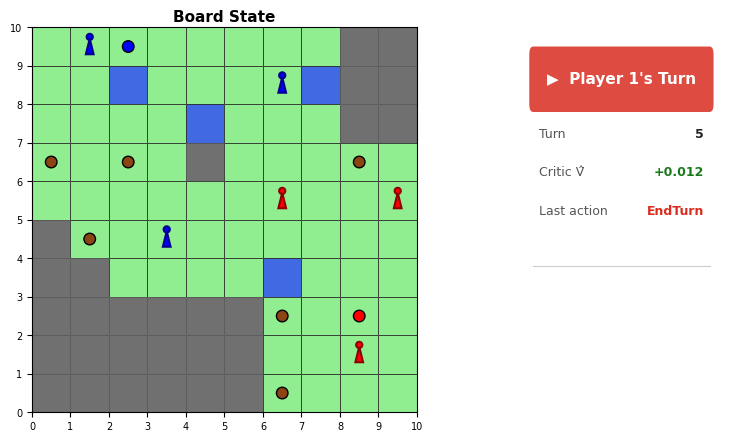

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0233)
logits:  tensor([-0.3260,  1.5117,  2.8142,  3.5816, -5.9259],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


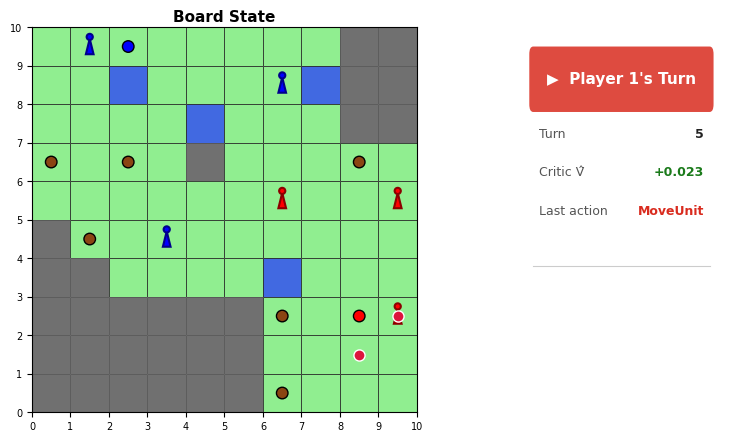

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.1052)
logits:  tensor([-0.3202,  1.5154,  2.8136,  3.5845, -5.9252],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


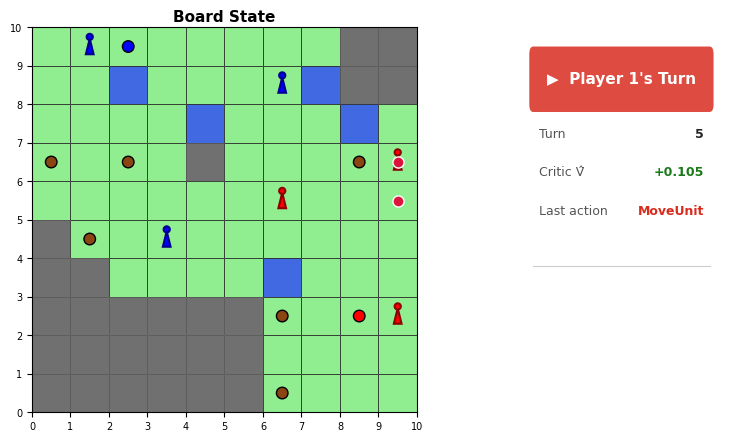

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state ready
value: tensor(0.0615)
logits:  tensor([-0.3205,  1.5151,  2.8140,  3.5835, -5.9260],
       grad_fn=<SqueezeBackward1>)
tensor([0.9963, 0.0000, 0.0000, 0.0000, 0.0037], grad_fn=<SoftmaxBackward0>)


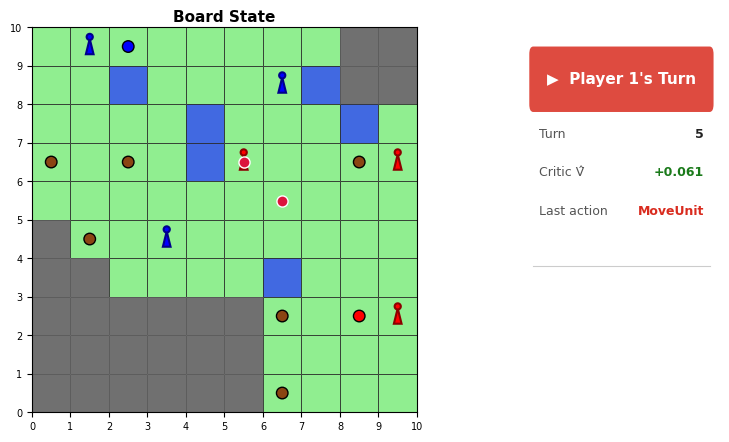

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0220)
logits:  tensor([-0.3171,  1.5173,  2.8148,  3.5828, -5.9278],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


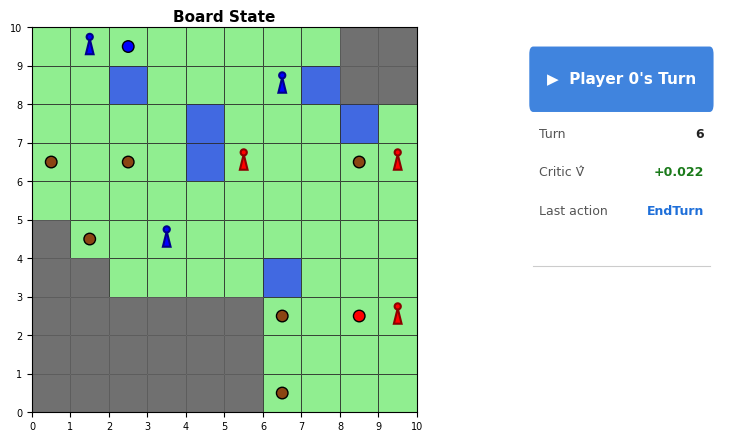

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0123)
logits:  tensor([-0.3147,  1.5187,  2.8154,  3.5827, -5.9286],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


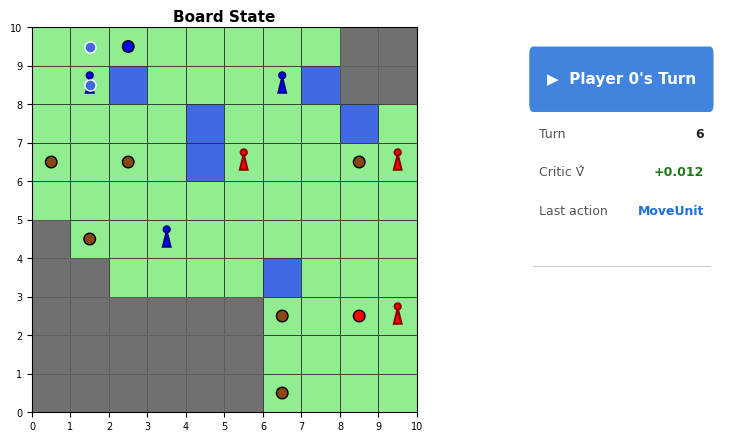

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0699)
logits:  tensor([-0.3076,  1.5229,  2.8149,  3.5854, -5.9283],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


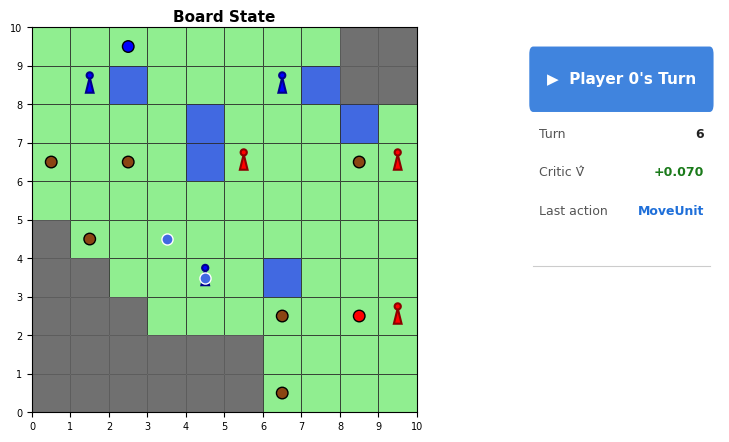

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0284)
logits:  tensor([-0.3045,  1.5247,  2.8160,  3.5843, -5.9301],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


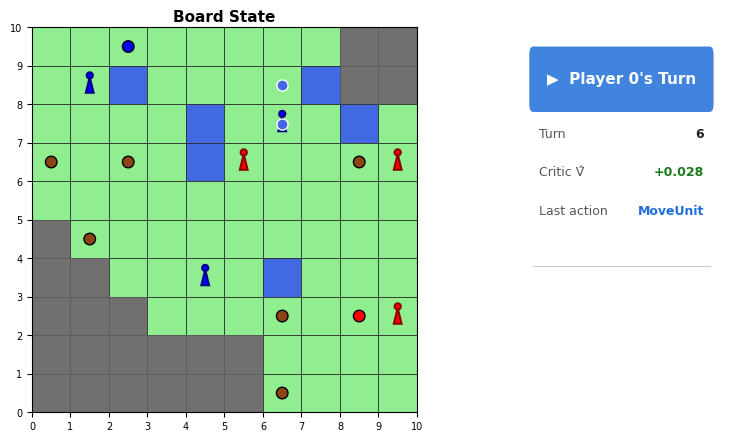

Warrior (10/10) in state idle
Warrior (10/10) in state can_hit
Warrior (10/10) in state idle
value: tensor(0.0092)
logits:  tensor([-0.3087,  1.5218,  2.8158,  3.5826, -5.9307],
       grad_fn=<SqueezeBackward1>)
tensor([0.0000e+00, 9.9942e-01, 0.0000e+00, 0.0000e+00, 5.7969e-04],
       grad_fn=<SoftmaxBackward0>)


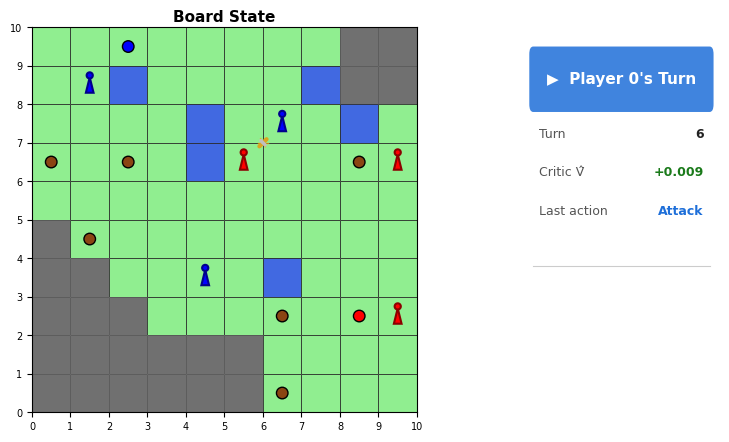

Warrior (10/10) in state idle
Warrior (5/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0112)
logits:  tensor([-0.3067,  1.5231,  2.8162,  3.5826, -5.9311],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


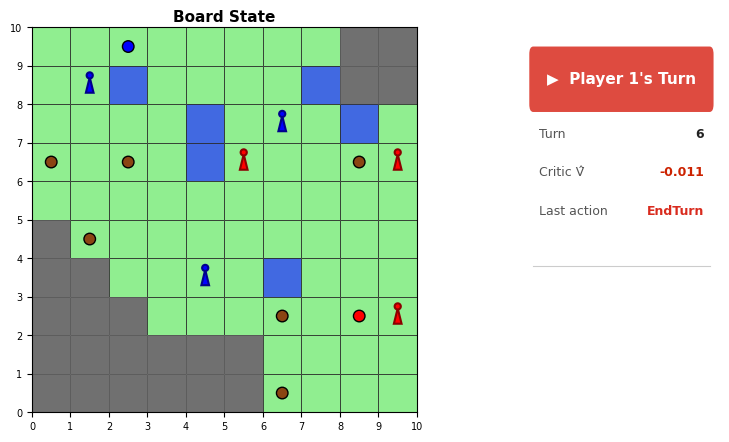

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (5/10) in state ready
value: tensor(0.0220)
logits:  tensor([-0.3171,  1.5173,  2.8148,  3.5828, -5.9278],
       grad_fn=<SqueezeBackward1>)
tensor([1.3764e-01, 8.6186e-01, 0.0000e+00, 0.0000e+00, 5.0354e-04],
       grad_fn=<SoftmaxBackward0>)


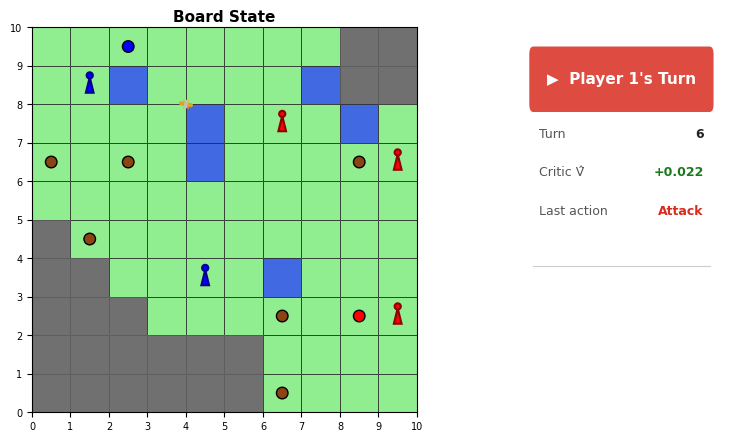

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (5/10) in state idle
value: tensor(0.0943)
logits:  tensor([-0.3047,  1.5250,  2.8148,  3.5859, -5.9289],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


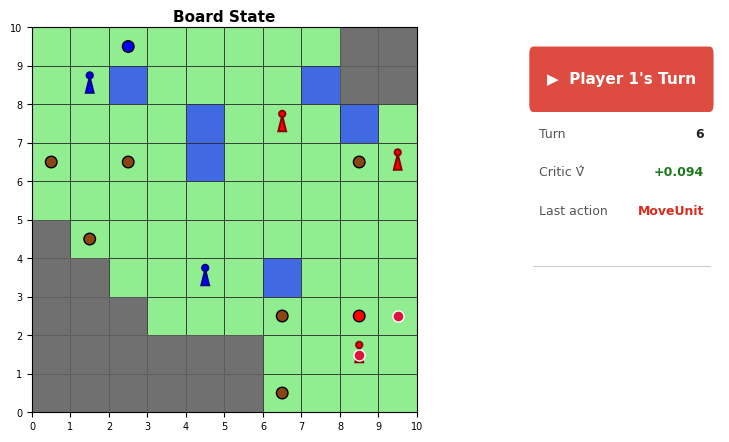

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (5/10) in state idle
value: tensor(0.0397)
logits:  tensor([-0.3073,  1.5233,  2.8151,  3.5844, -5.9295],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


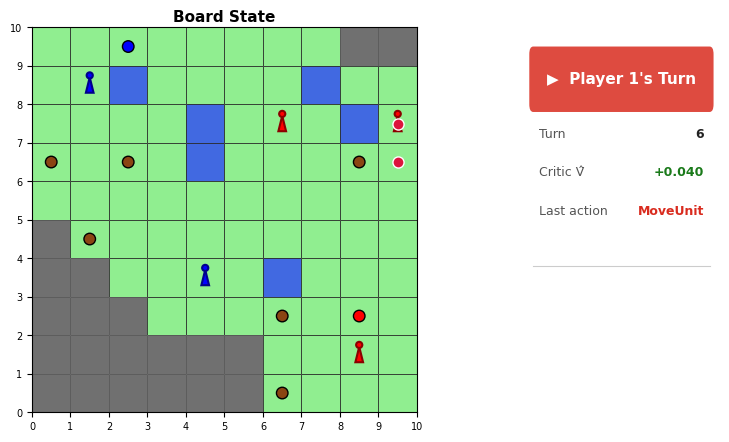

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (5/10) in state idle
value: tensor(-0.0024)
logits:  tensor([-0.3059,  1.5239,  2.8153,  3.5833, -5.9308],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


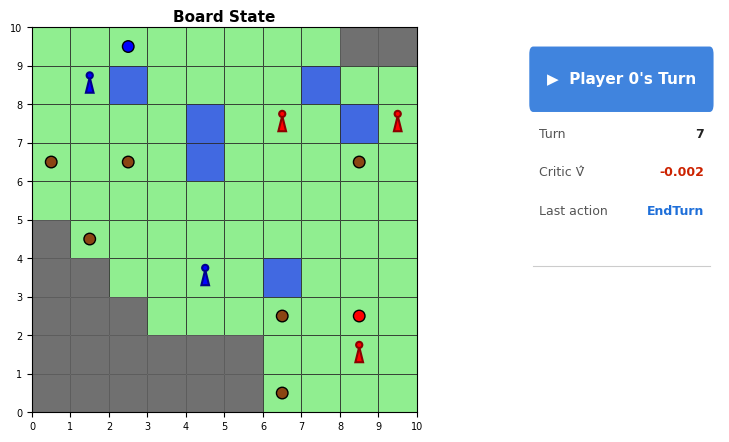

Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0185)
logits:  tensor([-0.3038,  1.5254,  2.8161,  3.5833, -5.9311],
       grad_fn=<SqueezeBackward1>)
tensor([4.2287e-02, 0.0000e+00, 9.5756e-01, 0.0000e+00, 1.5216e-04],
       grad_fn=<SoftmaxBackward0>)


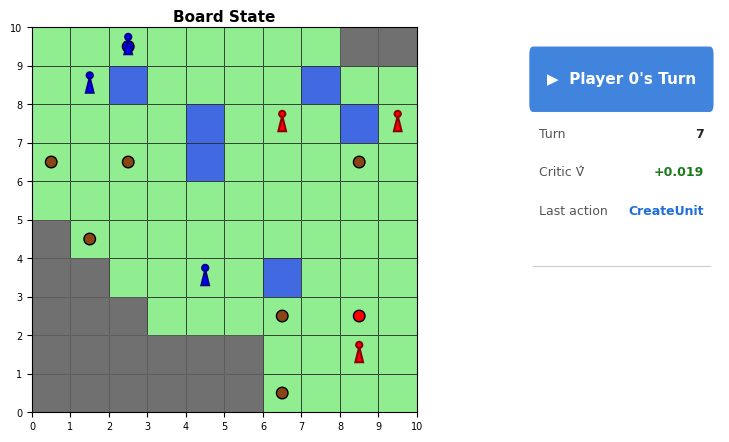

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0584)
logits:  tensor([-0.3008,  1.5268,  2.8155,  3.5854, -5.9305],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


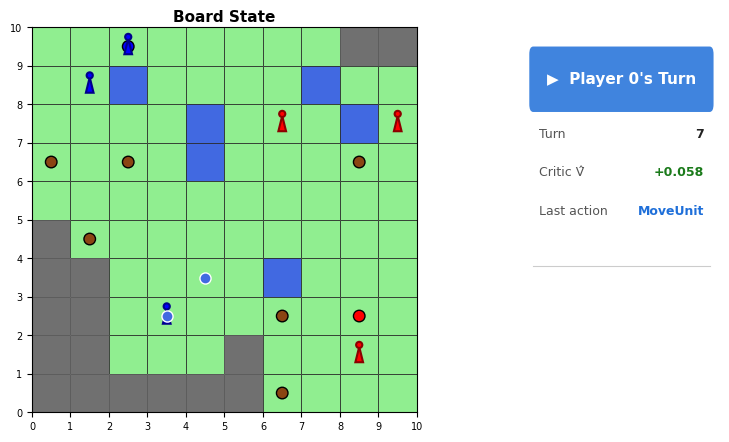

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0205)
logits:  tensor([-0.2983,  1.5284,  2.8156,  3.5839, -5.9326],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


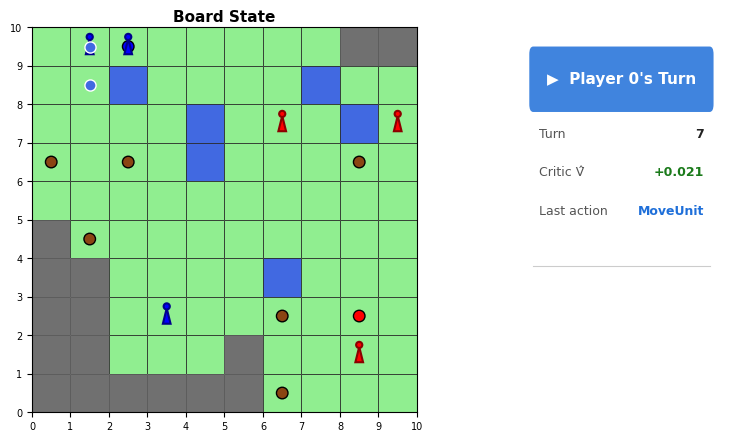

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0048)
logits:  tensor([-0.3016,  1.5265,  2.8160,  3.5826, -5.9326],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


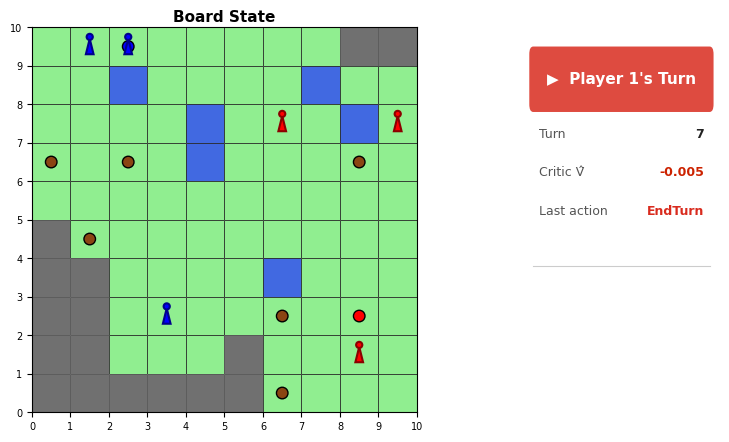

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (5/10) in state ready
value: tensor(-0.0024)
logits:  tensor([-0.3059,  1.5239,  2.8153,  3.5833, -5.9308],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


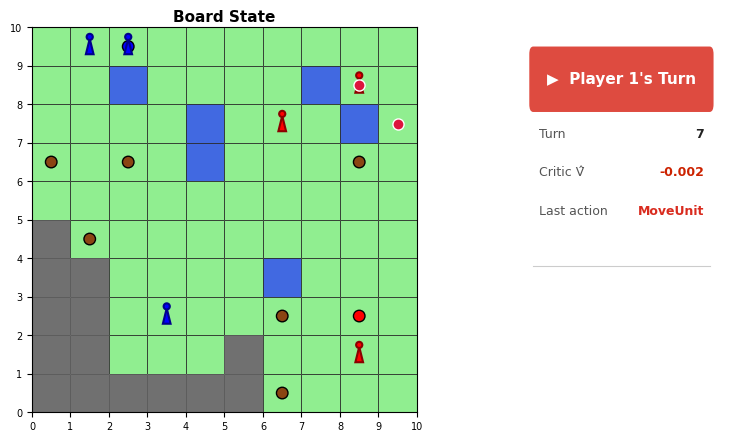

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (5/10) in state ready
value: tensor(0.0642)
logits:  tensor([-0.2945,  1.5309,  2.8140,  3.5860, -5.9323],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


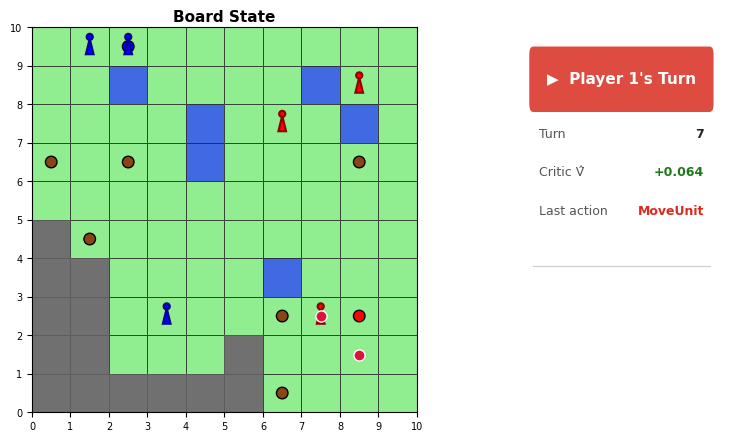

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (5/10) in state ready
value: tensor(-0.0061)
logits:  tensor([-0.2996,  1.5276,  2.8146,  3.5839, -5.9325],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


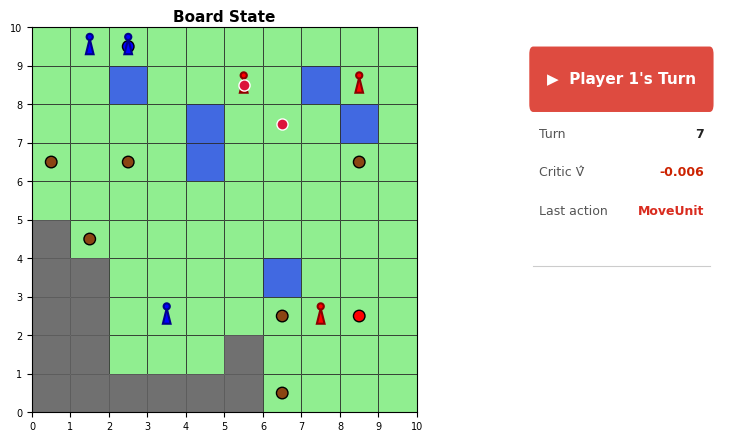

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (5/10) in state idle
value: tensor(-0.0313)
logits:  tensor([-0.2956,  1.5299,  2.8141,  3.5833, -5.9344],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


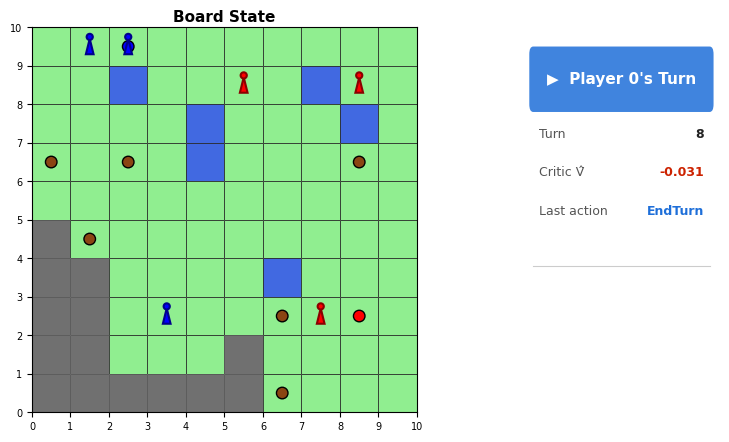

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0298)
logits:  tensor([-0.2980,  1.5291,  2.8160,  3.5835, -5.9326],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


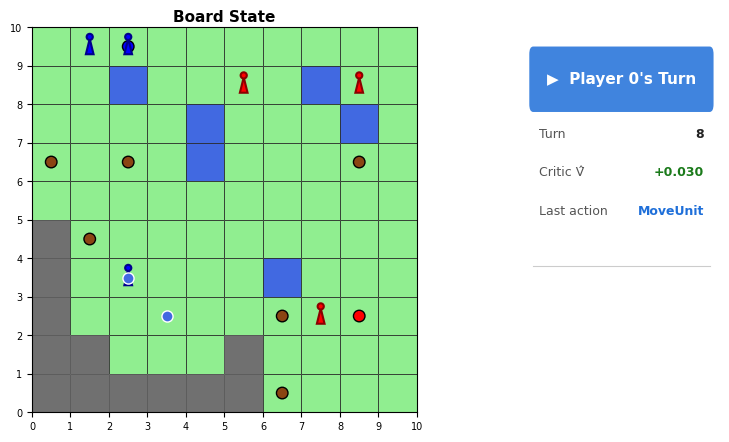

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0632)
logits:  tensor([-0.2942,  1.5312,  2.8152,  3.5845, -5.9333],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


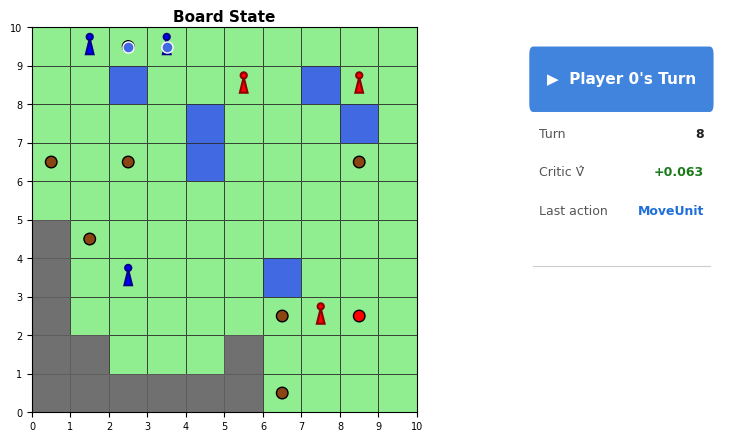

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0082)
logits:  tensor([-0.2968,  1.5294,  2.8154,  3.5833, -5.9336],
       grad_fn=<SqueezeBackward1>)
tensor([0.9964, 0.0000, 0.0000, 0.0000, 0.0036], grad_fn=<SoftmaxBackward0>)


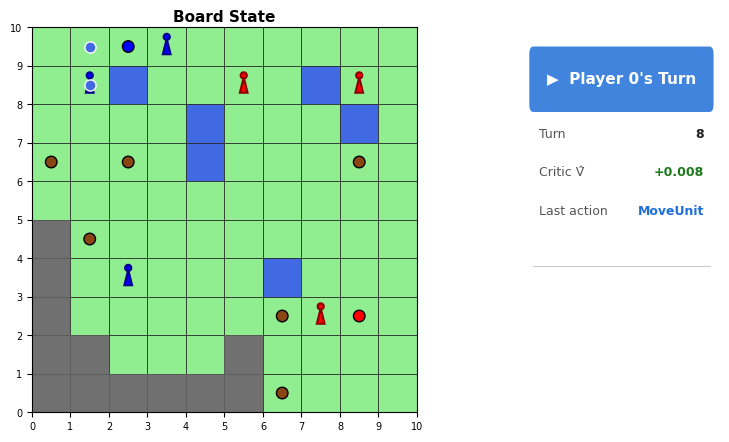

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0304)
logits:  tensor([-0.2989,  1.5279,  2.8155,  3.5821, -5.9340],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


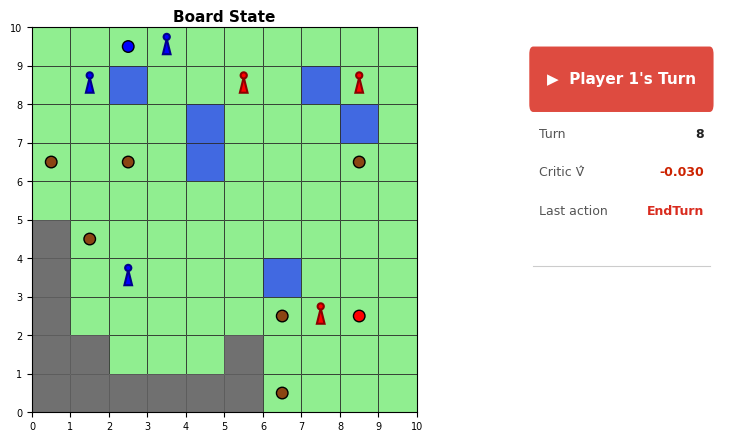

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (5/10) in state ready
value: tensor(-0.0313)
logits:  tensor([-0.2956,  1.5299,  2.8141,  3.5833, -5.9344],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


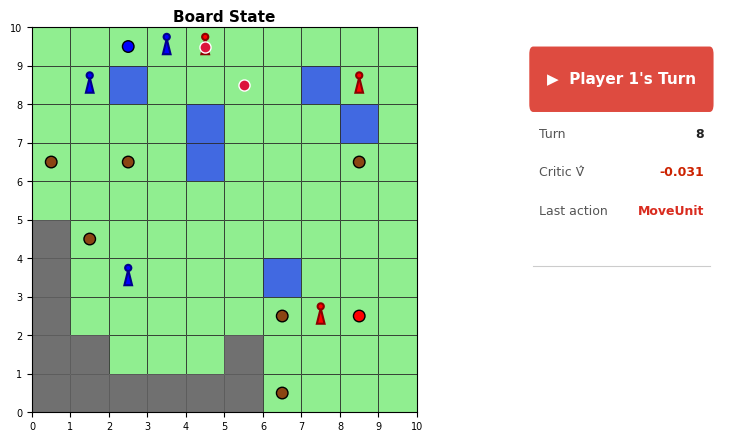

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (5/10) in state can_hit
value: tensor(0.0698)
logits:  tensor([-0.2893,  1.5337,  2.8127,  3.5860, -5.9344],
       grad_fn=<SqueezeBackward1>)
tensor([1.3900e-01, 8.6051e-01, 0.0000e+00, 0.0000e+00, 4.9136e-04],
       grad_fn=<SoftmaxBackward0>)


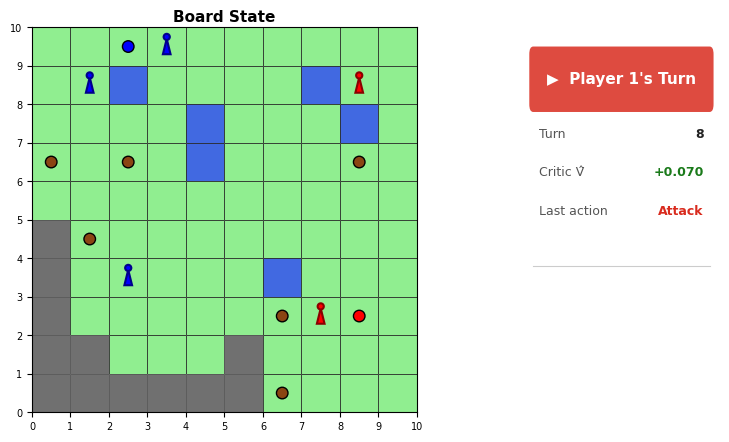

Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0665)
logits:  tensor([-0.2887,  1.5342,  2.8129,  3.5860, -5.9343],
       grad_fn=<SqueezeBackward1>)
tensor([4.3033e-02, 0.0000e+00, 9.5681e-01, 0.0000e+00, 1.5204e-04],
       grad_fn=<SoftmaxBackward0>)


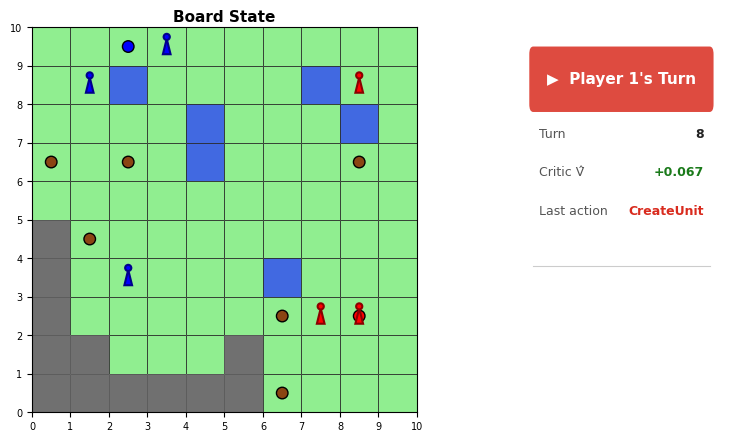

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0253)
logits:  tensor([-0.2892,  1.5336,  2.8130,  3.5853, -5.9349],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


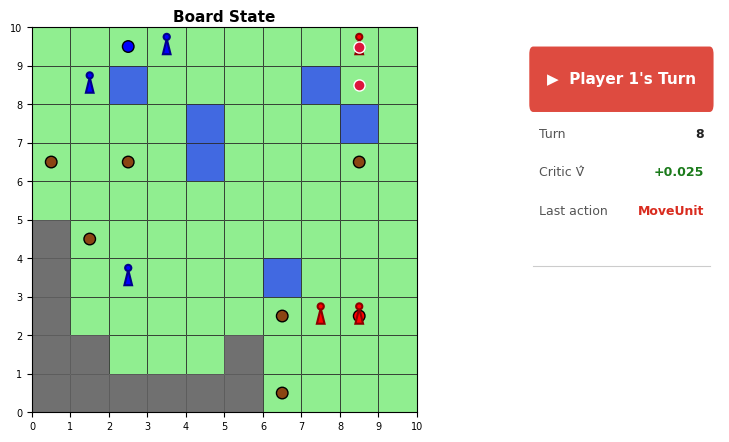

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0027)
logits:  tensor([-0.2927,  1.5315,  2.8135,  3.5841, -5.9349],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


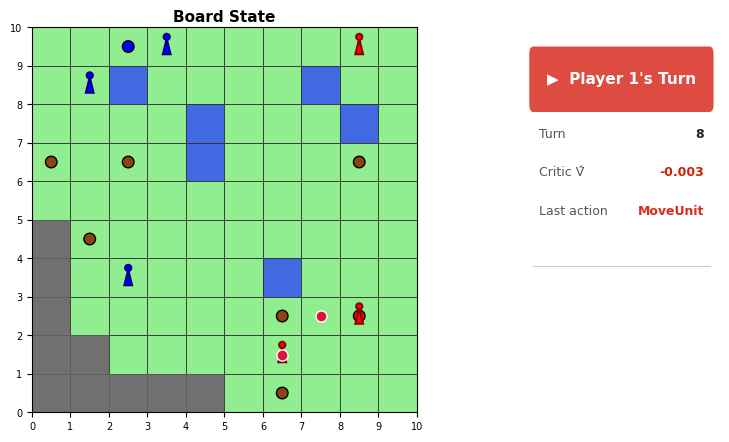

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0542)
logits:  tensor([-0.2914,  1.5325,  2.8142,  3.5822, -5.9363],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


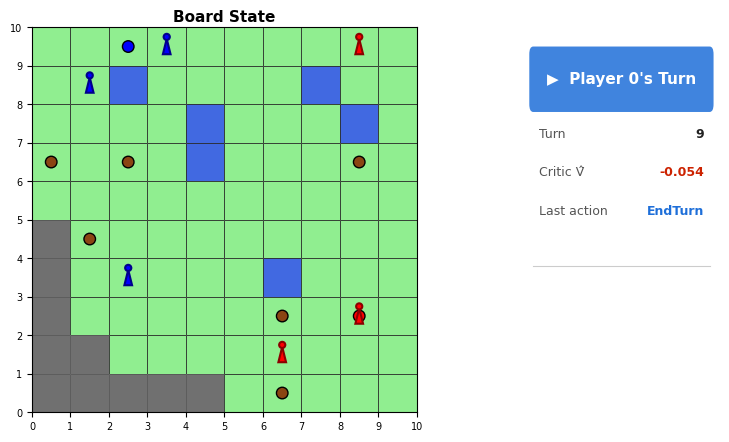

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (7/10) in state ready
value: tensor(0.0039)
logits:  tensor([-0.2950,  1.5309,  2.8154,  3.5829, -5.9341],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


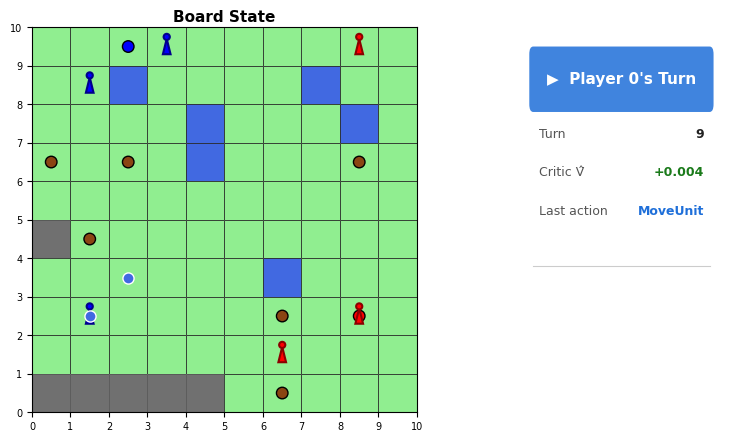

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (7/10) in state ready
value: tensor(0.0430)
logits:  tensor([-0.2825,  1.5384,  2.8139,  3.5848, -5.9362],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


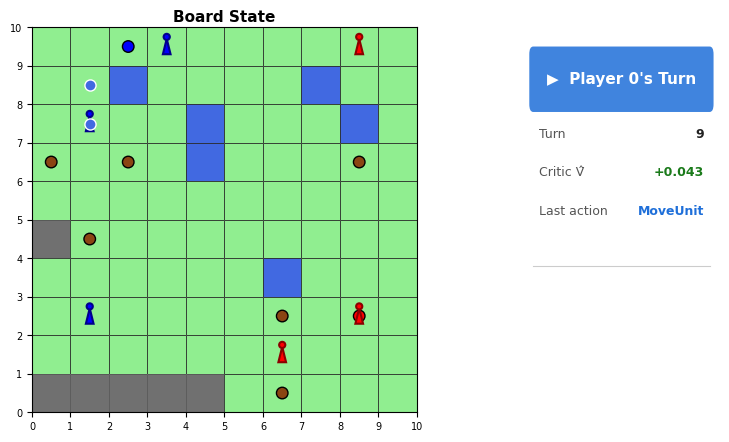

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (7/10) in state ready
value: tensor(-0.0203)
logits:  tensor([-0.2862,  1.5365,  2.8158,  3.5827, -5.9362],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


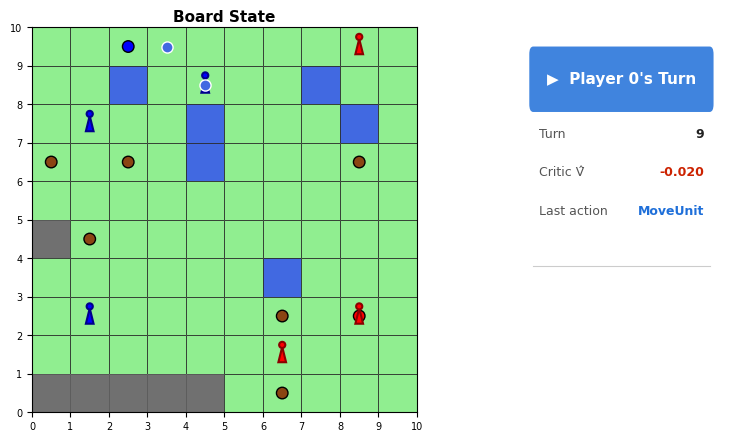

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (7/10) in state idle
value: tensor(-0.0394)
logits:  tensor([-0.2869,  1.5362,  2.8166,  3.5818, -5.9364],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


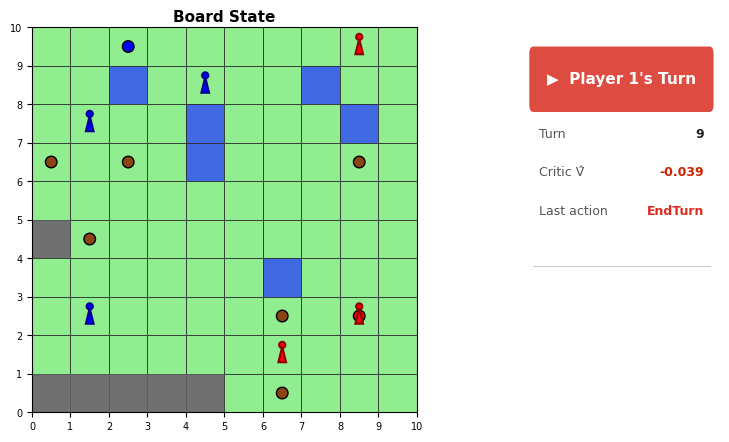

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(-0.0185)
logits:  tensor([-0.2880,  1.5349,  2.8142,  3.5832, -5.9362],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


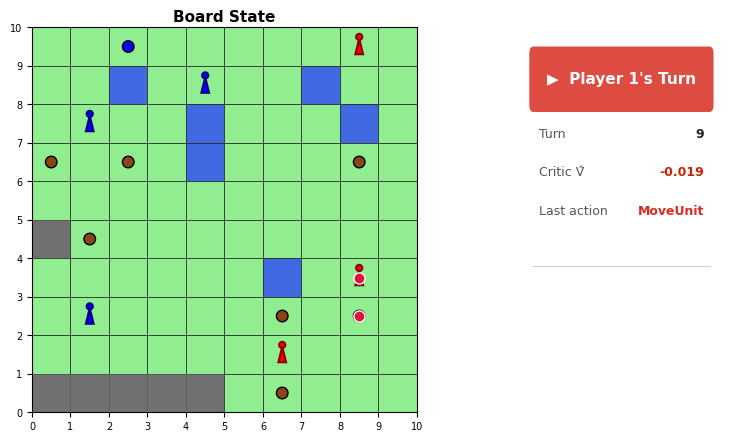

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0228)
logits:  tensor([-0.2875,  1.5347,  2.8128,  3.5847, -5.9359],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


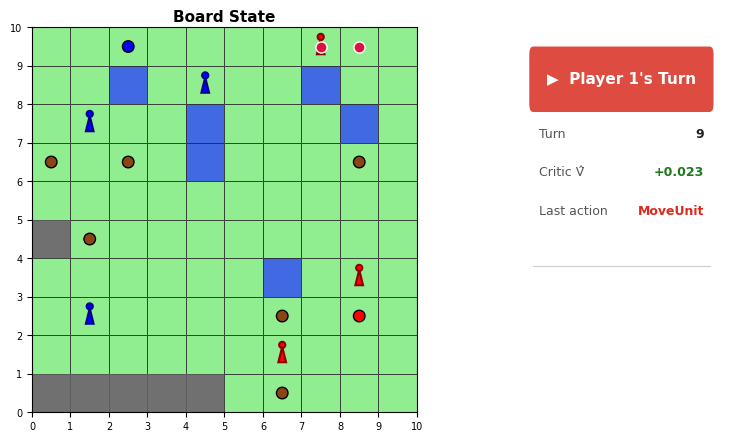

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(0.0027)
logits:  tensor([-0.2897,  1.5333,  2.8131,  3.5839, -5.9360],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


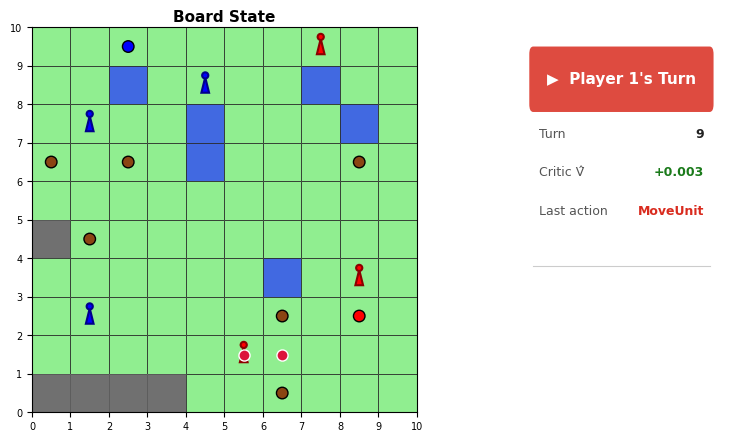

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0648)
logits:  tensor([-0.2890,  1.5343,  2.8153,  3.5813, -5.9371],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


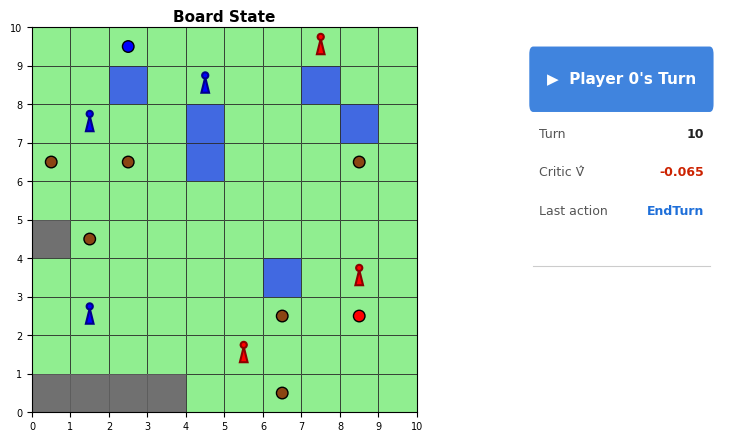

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (7/10) in state ready
value: tensor(-0.0394)
logits:  tensor([-0.2869,  1.5362,  2.8166,  3.5818, -5.9364],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


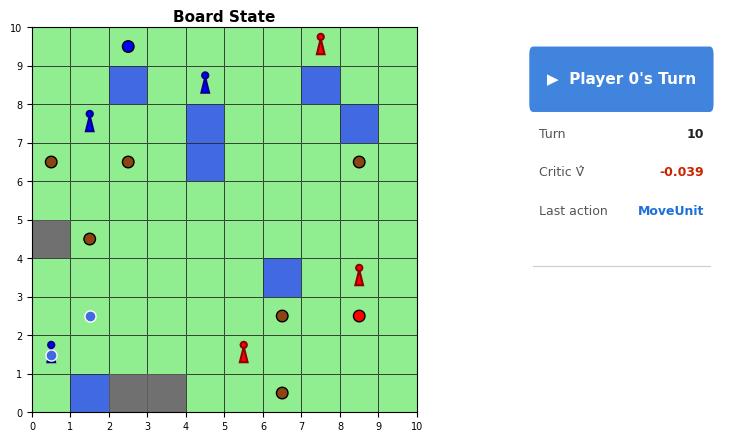

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (7/10) in state ready
value: tensor(0.0415)
logits:  tensor([-0.2827,  1.5379,  2.8130,  3.5847, -5.9368],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


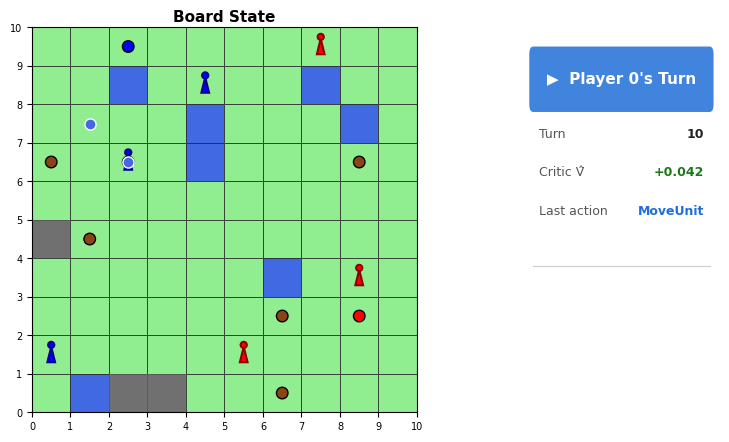

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (7/10) in state ready
value: tensor(-0.0195)
logits:  tensor([-0.2869,  1.5356,  2.8147,  3.5827, -5.9367],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


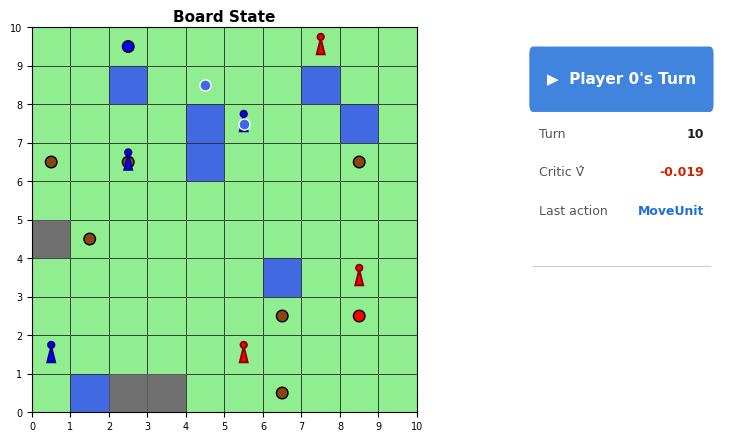

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (7/10) in state idle
value: tensor(-0.0453)
logits:  tensor([-0.2867,  1.5361,  2.8155,  3.5815, -5.9372],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


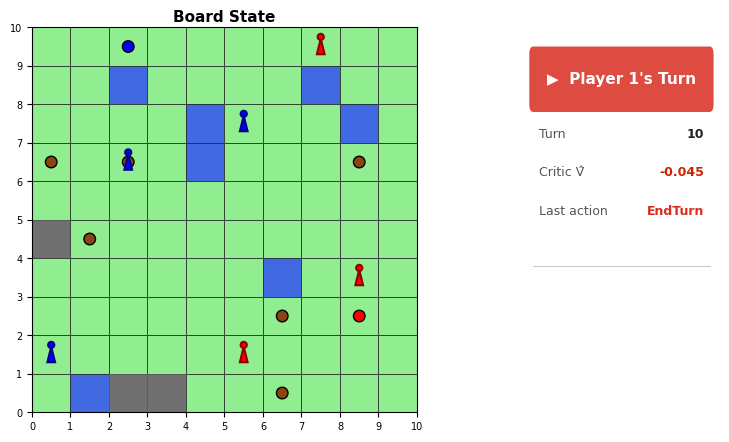

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(-0.0099)
logits:  tensor([-0.2838,  1.5381,  2.8150,  3.5826, -5.9372],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


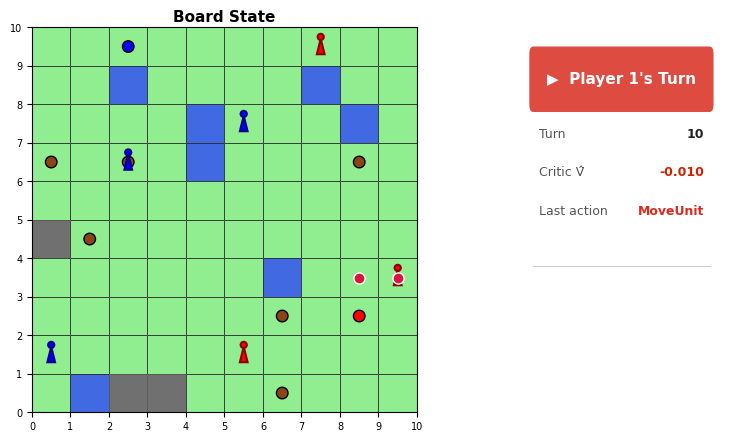

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(0.0223)
logits:  tensor([-0.2841,  1.5369,  2.8127,  3.5847, -5.9367],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


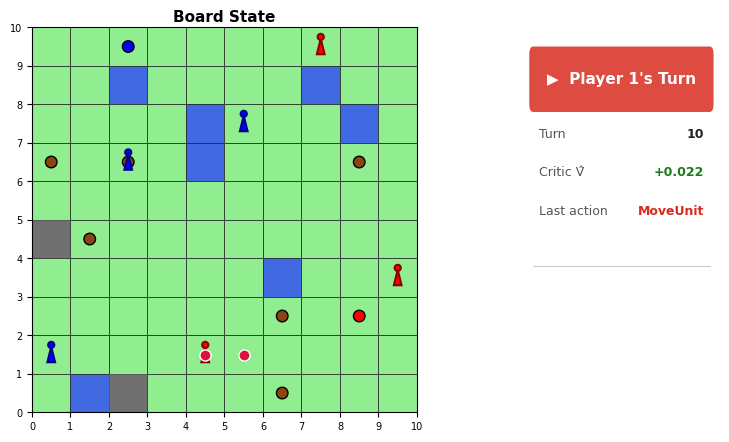

Warrior (10/10) in state idle
Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(-0.0351)
logits:  tensor([-0.2827,  1.5385,  2.8153,  3.5820, -5.9378],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


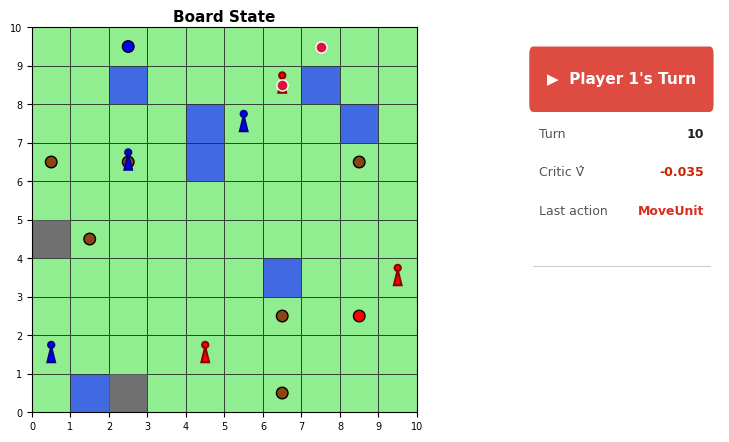

Warrior (10/10) in state idle
Warrior (10/10) in state can_hit
Warrior (10/10) in state idle
value: tensor(-0.0208)
logits:  tensor([-0.2849,  1.5373,  2.8154,  3.5818, -5.9375],
       grad_fn=<SqueezeBackward1>)
tensor([0.0000e+00, 9.9943e-01, 0.0000e+00, 0.0000e+00, 5.6685e-04],
       grad_fn=<SoftmaxBackward0>)


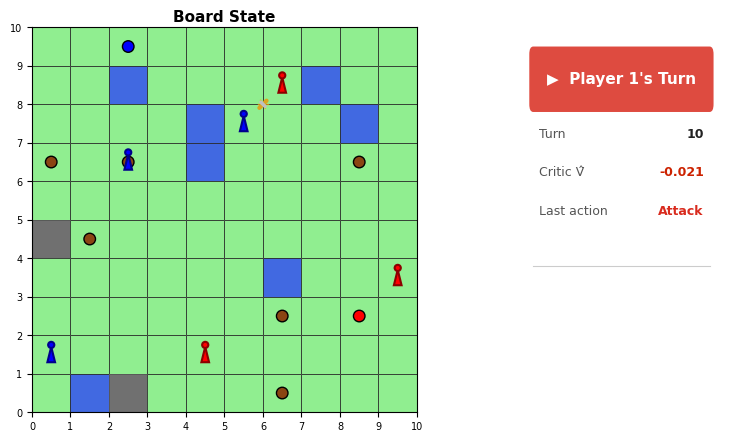

Warrior (10/10) in state idle
Warrior (6/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0423)
logits:  tensor([-0.2800,  1.5408,  2.8165,  3.5815, -5.9381],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


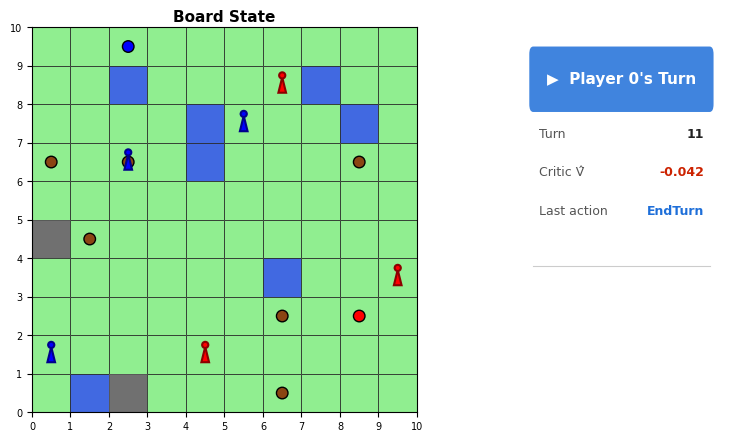

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (1/10) in state ready
value: tensor(0.0114)
logits:  tensor([-0.2819,  1.5395,  2.8153,  3.5829, -5.9372],
       grad_fn=<SqueezeBackward1>)
tensor([1.8221e-02, 1.1262e-01, 0.0000e+00, 8.6910e-01, 6.3760e-05],
       grad_fn=<SoftmaxBackward0>)


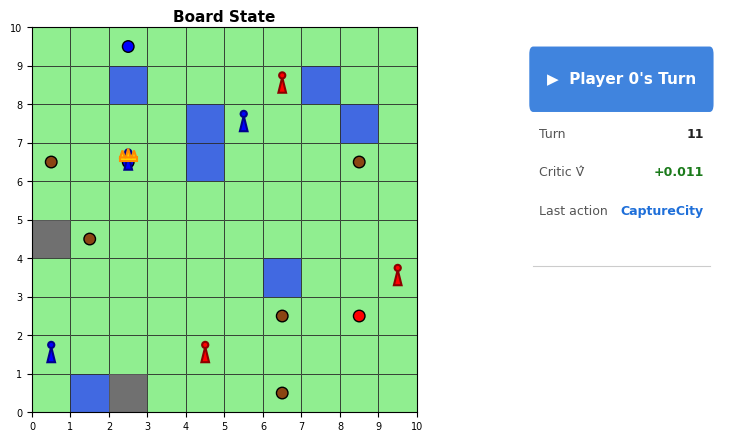

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (1/10) in state ready
value: tensor(-0.0221)
logits:  tensor([-0.2919,  1.5316,  2.8136,  3.5823, -5.9365],
       grad_fn=<SqueezeBackward1>)
tensor([3.3877e-02, 2.0981e-01, 7.5619e-01, 0.0000e+00, 1.1981e-04],
       grad_fn=<SoftmaxBackward0>)


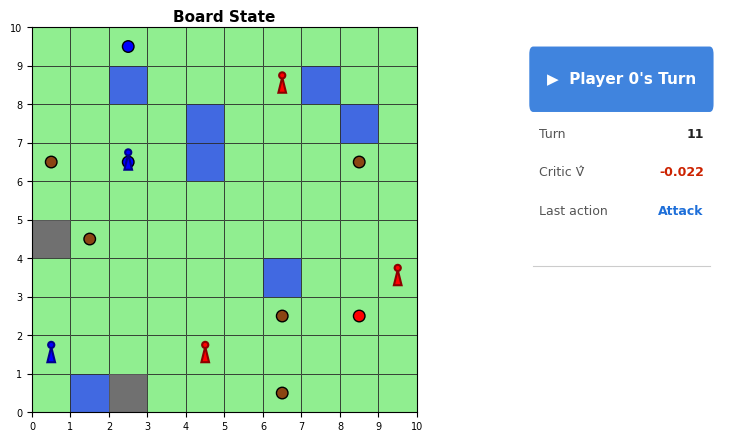

Warrior (10/10) in state ready
Warrior (10/10) in state idle
value: tensor(-0.0195)
logits:  tensor([-0.2908,  1.5325,  2.8138,  3.5824, -5.9366],
       grad_fn=<SqueezeBackward1>)
tensor([4.2913e-02, 0.0000e+00, 9.5694e-01, 0.0000e+00, 1.5158e-04],
       grad_fn=<SoftmaxBackward0>)


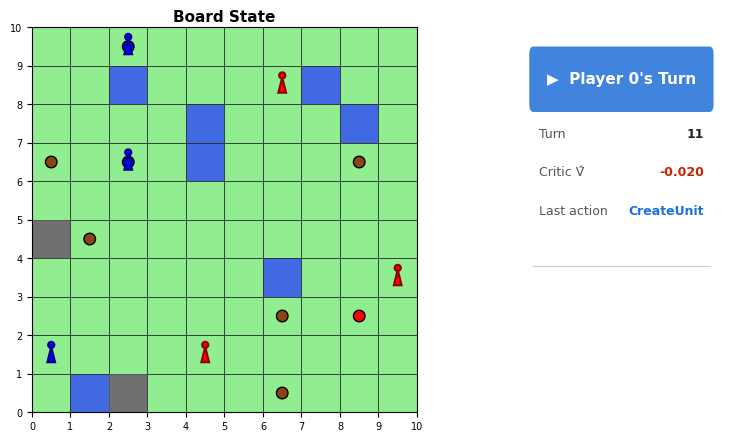

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0345)
logits:  tensor([-0.2902,  1.5329,  2.8143,  3.5820, -5.9368],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


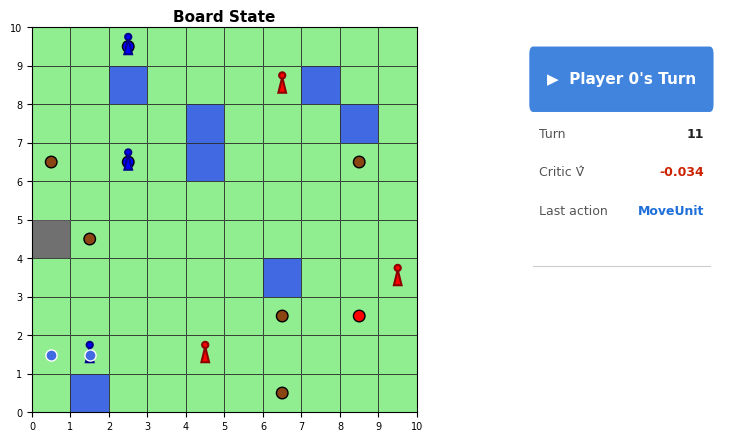

Warrior (10/10) in state idle
Warrior (10/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0666)
logits:  tensor([-0.2894,  1.5338,  2.8160,  3.5804, -5.9374],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


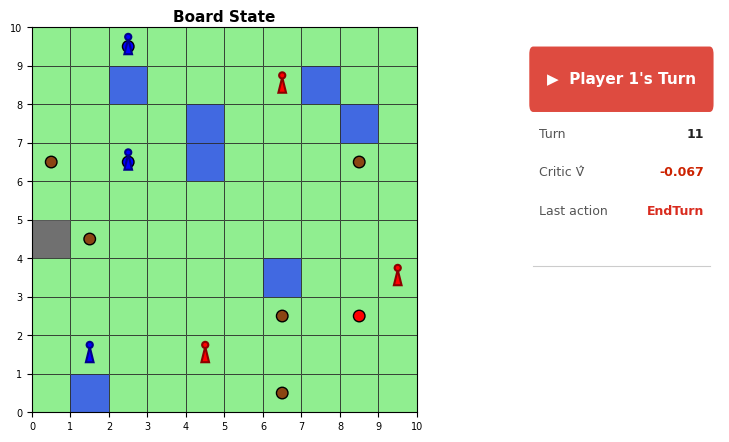

Warrior (10/10) in state ready
Warrior (4/10) in state ready
Warrior (10/10) in state ready
value: tensor(-0.0368)
logits:  tensor([-0.2794,  1.5413,  2.8165,  3.5816, -5.9381],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


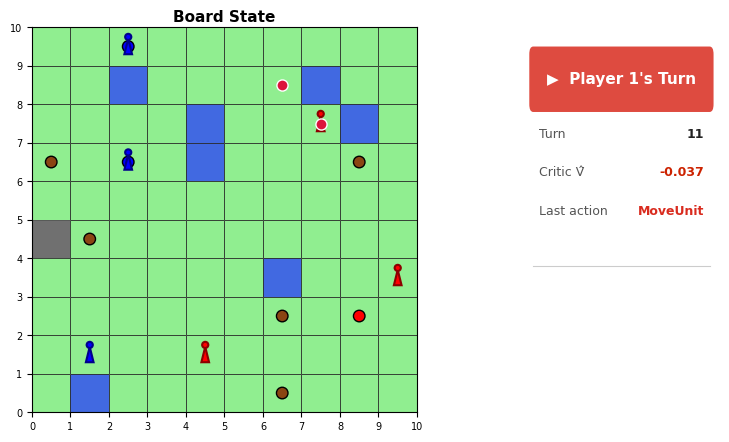

Warrior (10/10) in state ready
Warrior (4/10) in state idle
Warrior (10/10) in state ready
value: tensor(0.0388)
logits:  tensor([-0.2746,  1.5433,  2.8135,  3.5842, -5.9384],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


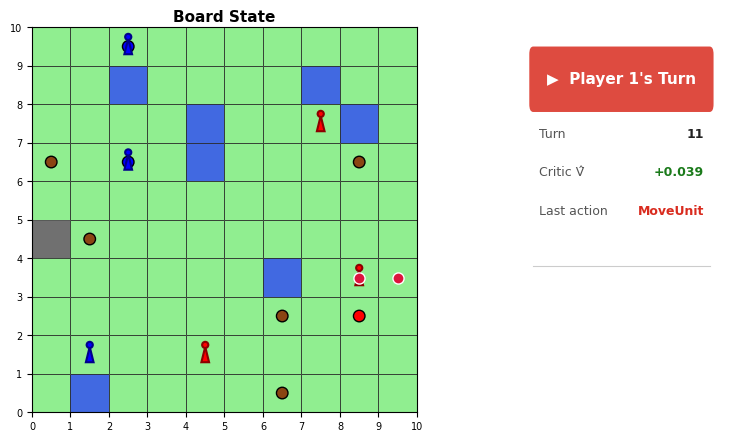

Warrior (10/10) in state ready
Warrior (4/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0062)
logits:  tensor([-0.2764,  1.5426,  2.8150,  3.5829, -5.9384],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


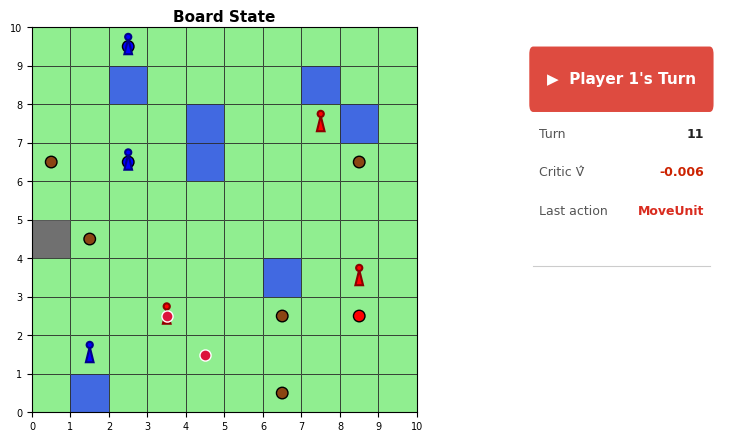

Warrior (10/10) in state idle
Warrior (4/10) in state idle
Warrior (10/10) in state idle
value: tensor(-0.0522)
logits:  tensor([-0.2710,  1.5470,  2.8180,  3.5799, -5.9401],
       grad_fn=<SqueezeBackward1>)
tensor([0., 0., 0., 0., 1.], grad_fn=<SoftmaxBackward0>)


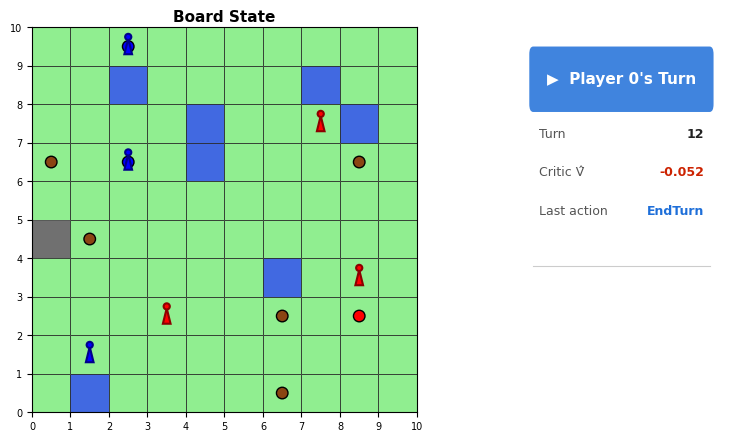

Warrior (10/10) in state ready
Warrior (10/10) in state ready
Warrior (10/10) in state ready
value: tensor(0.0433)
logits:  tensor([-0.2794,  1.5410,  2.8155,  3.5830, -5.9375],
       grad_fn=<SqueezeBackward1>)
tensor([0.9965, 0.0000, 0.0000, 0.0000, 0.0035], grad_fn=<SoftmaxBackward0>)


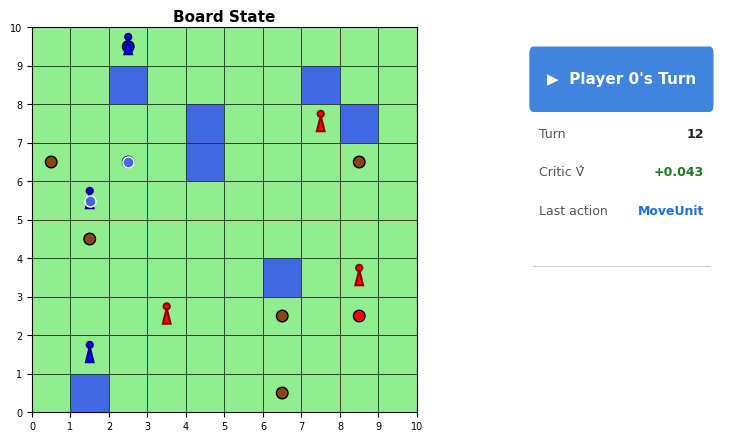

Warrior (10/10) in state ready
Warrior (10/10) in state idle
Warrior (10/10) in state ready

Game over — winner: Draw (turn limit)


In [8]:
env = EnvWrapper(board_config_dict, cfg.player_tribes,
                 max_turns_per_game=cfg.max_turns_per_game,
                 dense_reward=True)
obs  = env.reset()
done = False
step = 0

for i in range(100):
    mask             = env.get_action_mask()
    #print("-"*40,"Step {} mask".format(i),"-"*40,"\n",mask, "\n")
    
    with torch.no_grad():
        action, _, _, value = policy(obs, mask)

    print("value:", value)
    print(calc_probs_global_action_head(policy, obs, mask))
    translated_action = env._translate_action(action)
    obs, reward, done, info = env.step(action)

    
    #print(f"step {step:3d} | action: {info['log'].get('action_type')} | reward: {reward:.2f}")
    env.render(shared_fog=True, critic_value=value, translated_action=translated_action)
    for unit in env.game.players[env.game.player_go_id].units_under_control:
        #tile_id = unit.tile.id
        print(unit)
        #print(env.game.players[env.game.player_go_id].partial_graph[tile_id])
    step += 1

    if done:
        print("We have a winner!")
        break

    
winner = env.winner
print(f"\nGame over — winner: {'Player ' + str(winner) if winner is not None else 'Draw (turn limit)'}")